# 016: kmerseek vs OrthoFinder — Human-Mouse Ortholog Comparison

Compare kmerseek human-mouse ortholog predictions (filtered by raw, Bonferroni-corrected, and BH-corrected Poisson p-values) against OrthoFinder predictions, using Ensembl ortholog annotations as ground truth.

In [3]:
import csv
import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy.stats import poisson
from scipy.special import expit
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from statsmodels.stats.multitest import multipletests

plt.rcParams["figure.dpi"] = 120

## Paths

In [4]:
KSIZE = 24
DATA_DIR = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
ORTHOFINDER_DIR = Path(
    "/Users/olga/data/gencode/data-for-orthofinder/OrthoFinder/Results_Mar03"
)

EVAL_TSV = DATA_DIR / f"ortholog_evaluation.hp.k{KSIZE}.tsv"
ORTHOFINDER_ORTHOLOGS_TSV = (
    ORTHOFINDER_DIR
    / "Orthologues"
    / "Orthologues_gencode.v49.pc_translations"
    / "gencode.v49.pc_translations__v__gencode.vM38.pc_translations.tsv"
)

ALPHA = 0.05
SAMPLE_FRAC = 0.05  # 5% sample for speed

print(f"Eval TSV: {EVAL_TSV}")
print(f"OrthoFinder TSV: {ORTHOFINDER_ORTHOLOGS_TSV}")

Eval TSV: /Users/olga/data/gencode/results-human-mouse-orthologs/ortholog_evaluation.hp.k24.tsv
OrthoFinder TSV: /Users/olga/data/gencode/data-for-orthofinder/OrthoFinder/Results_Mar03/Orthologues/Orthologues_gencode.v49.pc_translations/gencode.v49.pc_translations__v__gencode.vM38.pc_translations.tsv


## 1. Load kmerseek evaluation data

In [5]:
df = pd.read_csv(
    EVAL_TSV,
    sep="\t",
    usecols=[
        "query_name",
        "target_name",
        "n_intersecting_hashes",
        "expected_shared_kmers",
        "prob_overlap",
        "enrichment",
        "query_tfidf",
        "containment",
        "is_ortholog",
    ],
    dtype={"is_ortholog": bool},
).sample(frac=SAMPLE_FRAC, random_state=42)

print(f"{len(df):,} rows loaded ({SAMPLE_FRAC*100:.0f}% sample)")
print(f"Orthologs:     {df['is_ortholog'].sum():,} ({df['is_ortholog'].mean():.2%})")
print(f"Non-orthologs: {(~df['is_ortholog']).sum():,}")

940,190 rows loaded (5% sample)
Orthologs:     34,399 (3.66%)
Non-orthologs: 905,791


### 1a. Compute Poisson p-values

In [6]:
k = df["n_intersecting_hashes"].values
lam = df["expected_shared_kmers"].values.clip(min=1e-300)

raw_p = poisson.sf(k - 1, lam)
df["poisson_p"] = raw_p

n_tests = len(df)
_, bh_p, _, _ = multipletests(raw_p, method="fdr_bh")
_, bonf_p, _, _ = multipletests(raw_p, method="bonferroni")

df["poisson_p_bh"] = bh_p
df["poisson_p_bonf"] = bonf_p

print(f"Rows with raw p < {ALPHA}: {(raw_p < ALPHA).sum():,}")
print(f"Rows with BH  p < {ALPHA}: {(bh_p  < ALPHA).sum():,}")
print(f"Rows with Bonf p < {ALPHA}: {(bonf_p < ALPHA).sum():,}")

Rows with raw p < 0.05: 863,692
Rows with BH  p < 0.05: 858,286
Rows with Bonf p < 0.05: 499,074


### Conservative Bonferroni correction (N_TOTAL = n_human_proteins × n_mouse_proteins)

The Bonferroni above uses `len(df)` (~18.8M pairs with ≥1 shared k-mer) as the denominator.
But the true search space is all possible pairwise comparisons. Pairs with zero k-mer overlap
have Poisson p=1 and were never tested, so they are missing from the denominator, making the
standard Bonferroni ~23× less stringent than it should be.

`poisson_p_bonf_conservative` uses N_HUMAN × N_MOUSE as the denominator (lower bound:
unique proteins that appeared in any matched pair).

In [ ]:
# Conservative multiple testing corrections: denominator = all possible pairwise comparisons
N_HUMAN = df["query_name"].nunique()
N_MOUSE = df["target_name"].nunique()
N_TOTAL_CONSERVATIVE = N_HUMAN * N_MOUSE
BONF_THRESHOLD_CONSERVATIVE = ALPHA / N_TOTAL_CONSERVATIVE
c_m = np.log(N_TOTAL_CONSERVATIVE) + 0.5772156649015329  # harmonic number ≈ ln(m) + γ

print(f"Unique human proteins in data: {N_HUMAN:,}")
print(f"Unique mouse proteins in data: {N_MOUSE:,}")
print(
    f"N_TOTAL_CONSERVATIVE:          {N_TOTAL_CONSERVATIVE:,}  ({N_TOTAL_CONSERVATIVE / len(df):.1f}x the tested pairs)"
)
print(
    f"Conservative Bonf raw p threshold: {BONF_THRESHOLD_CONSERVATIVE:.3e}  (vs standard {ALPHA / len(df):.3e})"
)
print(f"BY c_m ≈ ln(N)+γ = {c_m:.2f}  → BY is {c_m:.1f}x more conservative than BH")


def _bh_conservative(p_values, m_total):
    """BH FDR using m_total as total comparisons; no memory-intensive padding."""
    n = len(p_values)
    order = np.argsort(p_values)
    adj = p_values[order] * m_total / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    result = np.empty(n)
    result[order] = np.minimum(adj, 1.0)
    return result


def _by_conservative(p_values, m_total):
    """BY FDR (valid under arbitrary dependence) using m_total total comparisons."""
    _c_m = np.log(m_total) + 0.5772156649015329
    n = len(p_values)
    order = np.argsort(p_values)
    adj = p_values[order] * m_total * _c_m / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    result = np.empty(n)
    result[order] = np.minimum(adj, 1.0)
    return result


p_arr = df["poisson_p"].values
df["poisson_p_bonf_conservative"] = np.clip(p_arr * N_TOTAL_CONSERVATIVE, 0, 1)
df["poisson_p_bh_conservative"] = _bh_conservative(p_arr, N_TOTAL_CONSERVATIVE)
df["poisson_p_by_conservative"] = _by_conservative(p_arr, N_TOTAL_CONSERVATIVE)

print(
    f"\nRows passing standard    Bonf p < {ALPHA}: {(df['poisson_p_bonf'] < ALPHA).sum():,}"
)
print(
    f"Rows passing conservative Bonf p < {ALPHA}: {(df['poisson_p_bonf_conservative'] < ALPHA).sum():,}"
)
print(
    f"Rows passing conservative BH   p < {ALPHA}: {(df['poisson_p_bh_conservative'] < ALPHA).sum():,}"
)
print(
    f"Rows passing conservative BY   p < {ALPHA}: {(df['poisson_p_by_conservative'] < ALPHA).sum():,}"
)

### 1b. Extract protein IDs for joining

In [7]:
# Protein ID is the first pipe-delimited field of query_name / target_name
df["query_prot_id"] = df["query_name"].str.split("|").str[0]
df["target_prot_id"] = df["target_name"].str.split("|").str[0]

print("Example query_prot_id:", df["query_prot_id"].iloc[0])
print("Example target_prot_id:", df["target_prot_id"].iloc[0])

Example query_prot_id: ENSP00000245157.5
Example target_prot_id: ENSMUSP00000089555.5


## 2. Load OrthoFinder orthologues

In [8]:
def parse_orthofinder_pairs(tsv_path):
    """Parse OrthoFinder orthologues TSV into a set of (human_prot_id, mouse_prot_id) pairs.

    Each row lists comma-separated human proteins and comma-separated mouse proteins
    that are pairwise orthologs within the same orthogroup/node.
    Protein IDs are the first pipe-delimited field.
    """
    pairs = set()
    human_ids = set()
    mouse_ids = set()

    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            human_prots = [
                x.strip().split("|")[0]
                for x in row["gencode.v49.pc_translations"].split(",")
                if x.strip()
            ]
            mouse_prots = [
                x.strip().split("|")[0]
                for x in row["gencode.vM38.pc_translations"].split(",")
                if x.strip()
            ]
            for h, m in itertools.product(human_prots, mouse_prots):
                pairs.add((h, m))
            human_ids.update(human_prots)
            mouse_ids.update(mouse_prots)

    return pairs, human_ids, mouse_ids


print("Parsing OrthoFinder orthologues...")
of_pairs, of_human_ids, of_mouse_ids = parse_orthofinder_pairs(
    ORTHOFINDER_ORTHOLOGS_TSV
)
print(f"OrthoFinder pairwise ortholog pairs: {len(of_pairs):,}")
print(f"Unique human proteins: {len(of_human_ids):,}")
print(f"Unique mouse proteins: {len(of_mouse_ids):,}")

Parsing OrthoFinder orthologues...
OrthoFinder pairwise ortholog pairs: 468,432
Unique human proteins: 159,771
Unique mouse proteins: 54,250


### 2a. Add OrthoFinder label to kmerseek data

In [9]:
# Mark each kmerseek pair as OrthoFinder ortholog or not
df["is_orthofinder"] = [
    (h, m) in of_pairs for h, m in zip(df["query_prot_id"], df["target_prot_id"])
]

print(
    f"kmerseek pairs in OrthoFinder: {df['is_orthofinder'].sum():,} ({df['is_orthofinder'].mean():.2%})"
)
print(
    f"kmerseek Ensembl orthologs also in OrthoFinder: "
    f"{(df['is_ortholog'] & df['is_orthofinder']).sum():,}"
)
print(
    f"kmerseek Ensembl orthologs NOT in OrthoFinder: "
    f"{(df['is_ortholog'] & ~df['is_orthofinder']).sum():,}"
)

kmerseek pairs in OrthoFinder: 32,320 (3.44%)
kmerseek Ensembl orthologs also in OrthoFinder: 32,041
kmerseek Ensembl orthologs NOT in OrthoFinder: 2,358


## 3. Summary statistics

In [10]:
def confusion_stats(y_true, y_pred):
    tp = (y_true & y_pred).sum()
    fp = (~y_true & y_pred).sum()
    fn = (y_true & ~y_pred).sum()
    tn = (~y_true & ~y_pred).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    )
    return dict(
        TP=tp,
        FP=fp,
        FN=fn,
        TN=tn,
        precision=precision,
        recall=recall,
        f1=f1,
        n_predicted=y_pred.sum(),
    )


y_true = df["is_ortholog"]

rows = [
    ("OrthoFinder", confusion_stats(y_true, df["is_orthofinder"])),
    ("kmerseek raw p<0.05", confusion_stats(y_true, df["poisson_p"] < ALPHA)),
    ("kmerseek BH  p<0.05", confusion_stats(y_true, df["poisson_p_bh"] < ALPHA)),
    ("kmerseek Bonf p<0.05", confusion_stats(y_true, df["poisson_p_bonf"] < ALPHA)),
    ("kmerseek raw p<1e-5", confusion_stats(y_true, df["poisson_p"] < 1e-5)),
    ("kmerseek BH  p<1e-5", confusion_stats(y_true, df["poisson_p_bh"] < 1e-5)),
    ("kmerseek Bonf p<1e-5", confusion_stats(y_true, df["poisson_p_bonf"] < 1e-5)),
]

summary = pd.DataFrame(
    [{**{"method": name}, **stats} for name, stats in rows]
).set_index("method")

display(
    summary[["n_predicted", "TP", "FP", "FN", "precision", "recall", "f1"]].round(3)
)

,n_predicted,TP,FP,FN,precision,recall,f1
method,,,,,,,
OrthoFinder,32320,32041,279,2358,0.991,0.931,0.960
kmerseek raw p<0.05,863692,34397,829295,2,0.040,1.000,0.077
kmerseek BH p<0.05,858286,34397,823889,2,0.040,1.000,0.077
kmerseek Bonf p<0.05,499074,34339,464735,60,0.069,0.998,0.129
kmerseek raw p<1e-5,608594,34364,574230,35,0.056,0.999,0.107
kmerseek BH p<1e-5,589848,34364,555484,35,0.058,0.999,0.110
kmerseek Bonf p<1e-5,373225,34312,338913,87,0.092,0.997,0.168


In [ ]:
# Conservative corrections vs ground truth — shown here since confusion_stats() is now defined
y_true = df["is_ortholog"]

conservative_rows = [
    (
        "kmerseek conservative Bonf p<0.05",
        confusion_stats(y_true, df["poisson_p_bonf_conservative"] < ALPHA),
    ),
    (
        "kmerseek conservative BH   p<0.05",
        confusion_stats(y_true, df["poisson_p_bh_conservative"] < ALPHA),
    ),
    (
        "kmerseek conservative BY   p<0.05",
        confusion_stats(y_true, df["poisson_p_by_conservative"] < ALPHA),
    ),
    (
        "kmerseek standard Bonf p<0.05",
        confusion_stats(y_true, df["poisson_p_bonf"] < ALPHA),
    ),
    (
        "kmerseek standard BH   p<0.05",
        confusion_stats(y_true, df["poisson_p_bh"] < ALPHA),
    ),
    ("kmerseek raw p<0.05", confusion_stats(y_true, df["poisson_p"] < ALPHA)),
    ("OrthoFinder", confusion_stats(y_true, df["is_orthofinder"])),
]

cons_summary = pd.DataFrame(
    [{"method": name, **stats} for name, stats in conservative_rows]
).set_index("method")

print(
    f"N_TOTAL_CONSERVATIVE = {N_TOTAL_CONSERVATIVE:,}  (raw p threshold: {BONF_THRESHOLD_CONSERVATIVE:.3e})"
)
print(f"BY c_m ≈ {c_m:.2f}")
print()
display(
    cons_summary[["n_predicted", "TP", "FP", "FN", "precision", "recall", "f1"]].round(
        3
    )
)

## 4. Precision-Recall curves: kmerseek metrics vs OrthoFinder point

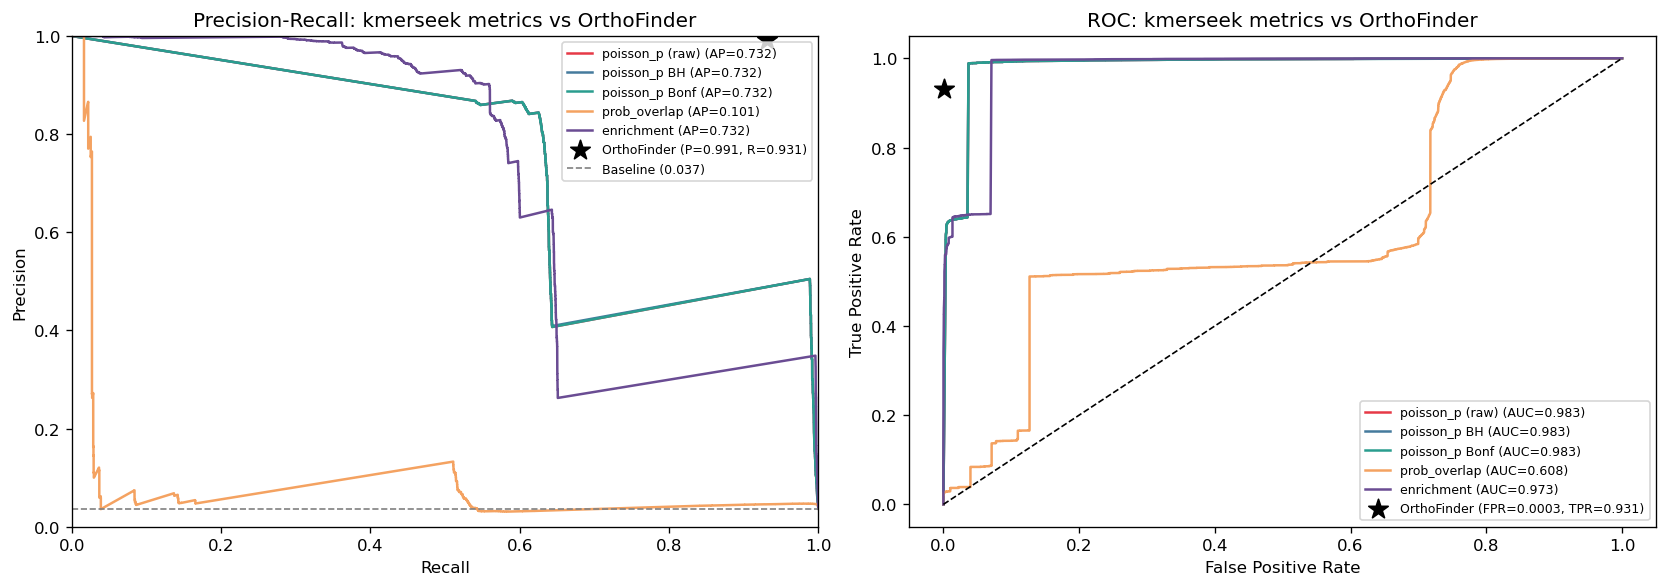

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Precision-Recall ---
ax = axes[0]
metrics_pr = [
    ("poisson_p (raw)", -df["poisson_p"], "#e63946"),
    ("poisson_p BH", -df["poisson_p_bh"], "#457b9d"),
    ("poisson_p Bonf", -df["poisson_p_bonf"], "#2a9d8f"),
    ("prob_overlap", df["prob_overlap"], "#f4a261"),
    ("enrichment", df["enrichment"], "#6a4c93"),
]

for label, scores, color in metrics_pr:
    prec, rec, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    ax.plot(rec, prec, lw=1.5, color=color, label=f"{label} (AP={ap:.3f})")

# OrthoFinder as a point
of_stats = confusion_stats(y_true, df["is_orthofinder"])
ax.scatter(
    of_stats["recall"],
    of_stats["precision"],
    s=150,
    zorder=5,
    color="black",
    marker="*",
    label=f"OrthoFinder (P={of_stats['precision']:.3f}, R={of_stats['recall']:.3f})",
)

baseline = y_true.mean()
ax.axhline(baseline, color="grey", lw=1, ls="--", label=f"Baseline ({baseline:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall: kmerseek metrics vs OrthoFinder")
ax.legend(fontsize=7.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Right: ROC ---
ax = axes[1]
for label, scores, color in metrics_pr:
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.5, color=color, label=f"{label} (AUC={roc_auc:.3f})")

# OrthoFinder as a point (TPR = recall, FPR = FP/(FP+TN))
of_fpr = of_stats["FP"] / (of_stats["FP"] + of_stats["TN"])
of_tpr = of_stats["recall"]
ax.scatter(
    of_fpr,
    of_tpr,
    s=150,
    zorder=5,
    color="black",
    marker="*",
    label=f"OrthoFinder (FPR={of_fpr:.4f}, TPR={of_tpr:.3f})",
)

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: kmerseek metrics vs OrthoFinder")
ax.legend(fontsize=7.5)

fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_pr_roc.hp.k{KSIZE}.png", dpi=150)
plt.show()

## 5. F1/Precision/Recall vs threshold for each p-value correction

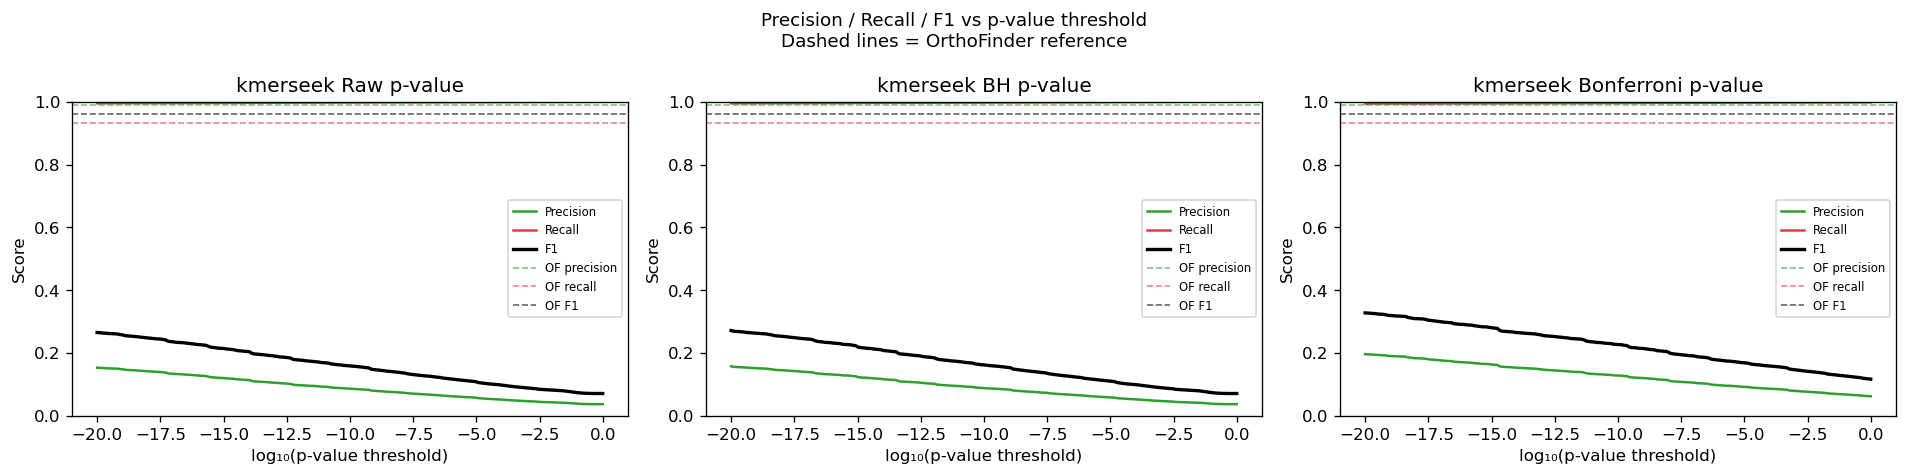

In [12]:
thresholds = np.logspace(-20, 0, 200)


def sweep_thresholds(pvals, y_true, thresholds):
    records = []
    for thr in thresholds:
        s = confusion_stats(y_true, pvals < thr)
        s["threshold"] = thr
        records.append(s)
    return pd.DataFrame(records)


sweep_raw = sweep_thresholds(df["poisson_p"], y_true, thresholds)
sweep_bh = sweep_thresholds(df["poisson_p_bh"], y_true, thresholds)
sweep_bonf = sweep_thresholds(df["poisson_p_bonf"], y_true, thresholds)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, sweep, label, color in [
    (axes[0], sweep_raw, "Raw", "#e63946"),
    (axes[1], sweep_bh, "BH", "#457b9d"),
    (axes[2], sweep_bonf, "Bonferroni", "#2a9d8f"),
]:
    log_thr = np.log10(sweep["threshold"])
    ax.plot(log_thr, sweep["precision"], color="#2ca02c", lw=1.5, label="Precision")
    ax.plot(log_thr, sweep["recall"], color="#e63946", lw=1.5, label="Recall")
    ax.plot(log_thr, sweep["f1"], color="k", lw=2, label="F1")

    # OrthoFinder reference lines
    ax.axhline(
        of_stats["precision"],
        ls="--",
        color="#2ca02c",
        lw=1,
        alpha=0.6,
        label="OF precision",
    )
    ax.axhline(
        of_stats["recall"], ls="--", color="#e63946", lw=1, alpha=0.6, label="OF recall"
    )
    ax.axhline(of_stats["f1"], ls="--", color="k", lw=1, alpha=0.6, label="OF F1")

    ax.set_title(f"kmerseek {label} p-value")
    ax.set_xlabel("log₁₀(p-value threshold)")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)

fig.suptitle(
    "Precision / Recall / F1 vs p-value threshold\n"
    "Dashed lines = OrthoFinder reference",
    fontsize=11,
)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_threshold_sweep.hp.k{KSIZE}.png", dpi=150)
plt.show()

## 6. Overlap between kmerseek and OrthoFinder predictions

In [13]:
# Compare predicted sets for several kmerseek thresholds vs OrthoFinder
methods = [
    ("raw p<0.05", df["poisson_p"] < ALPHA),
    ("BH p<0.05", df["poisson_p_bh"] < ALPHA),
    ("Bonf p<0.05", df["poisson_p_bonf"] < ALPHA),
    ("raw p<1e-5", df["poisson_p"] < 1e-5),
    ("BH p<1e-5", df["poisson_p_bh"] < 1e-5),
    ("Bonf p<1e-5", df["poisson_p_bonf"] < 1e-5),
]

of_pred = df["is_orthofinder"]

overlap_rows = []
for name, km_pred in methods:
    both = (km_pred & of_pred).sum()
    km_only = (km_pred & ~of_pred).sum()
    of_only = (~km_pred & of_pred).sum()
    neither = (~km_pred & ~of_pred).sum()
    km_total = km_pred.sum()
    of_total = of_pred.sum()
    jaccard = (
        both / (km_total + of_total - both) if (km_total + of_total - both) > 0 else 0
    )
    overlap_rows.append(
        dict(
            method=name,
            kmerseek_n=km_total,
            orthofinder_n=of_total,
            both=both,
            kmerseek_only=km_only,
            orthofinder_only=of_only,
            jaccard=jaccard,
        )
    )

overlap_df = pd.DataFrame(overlap_rows).set_index("method")
display(overlap_df.round(3))

,kmerseek_n,orthofinder_n,both,kmerseek_only,orthofinder_only,jaccard
method,,,,,,
raw p<0.05,863692,32320,32319,831373,1,0.037
BH p<0.05,858286,32320,32319,825967,1,0.038
Bonf p<0.05,499074,32320,32288,466786,32,0.065
raw p<1e-5,608594,32320,32306,576288,14,0.053
BH p<1e-5,589848,32320,32306,557542,14,0.055
Bonf p<1e-5,373225,32320,32270,340955,50,0.086


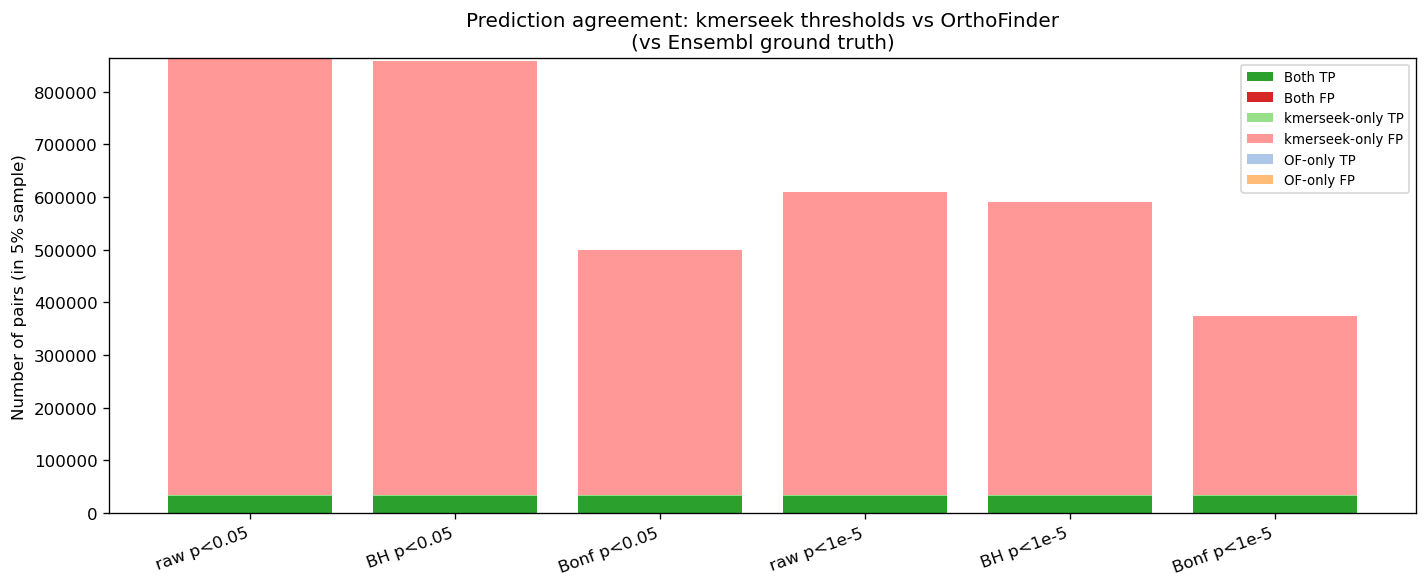

In [14]:
# Stacked bar: agreement breakdown per threshold
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(methods))
labels = [n for n, _ in methods]

# Categories: TP (both predict, Ensembl ortholog), FP-shared (both predict, not ortholog),
#             kmerseek-only-TP, kmerseek-only-FP, OF-only-TP, OF-only-FP
cats = {
    "Both + ortholog (TP)": (y_true & df["is_orthofinder"]),
    "Both + non-ortholog (FP)": (~y_true & df["is_orthofinder"]),
}

bar_data = []
for name, km_pred in methods:
    both_tp = (km_pred & of_pred & y_true).sum()
    both_fp = (km_pred & of_pred & ~y_true).sum()
    km_tp = (km_pred & ~of_pred & y_true).sum()
    km_fp = (km_pred & ~of_pred & ~y_true).sum()
    of_tp = (~km_pred & of_pred & y_true).sum()
    of_fp = (~km_pred & of_pred & ~y_true).sum()
    bar_data.append([both_tp, both_fp, km_tp, km_fp, of_tp, of_fp])

bar_data = np.array(bar_data)
colors = ["#2ca02c", "#d62728", "#98df8a", "#ff9896", "#aec7e8", "#ffbb78"]
cat_names = [
    "Both TP",
    "Both FP",
    "kmerseek-only TP",
    "kmerseek-only FP",
    "OF-only TP",
    "OF-only FP",
]

bottom = np.zeros(len(methods))
for i, (col, cname) in enumerate(zip(colors, cat_names)):
    ax.bar(x, bar_data[:, i], bottom=bottom, color=col, label=cname)
    bottom += bar_data[:, i]

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Number of pairs (in 5% sample)")
ax.set_title(
    "Prediction agreement: kmerseek thresholds vs OrthoFinder\n(vs Ensembl ground truth)"
)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_overlap_bars.hp.k{KSIZE}.png", dpi=150)
plt.show()

## 7. Distribution of kmerseek scores: OrthoFinder-agree vs OrthoFinder-disagree

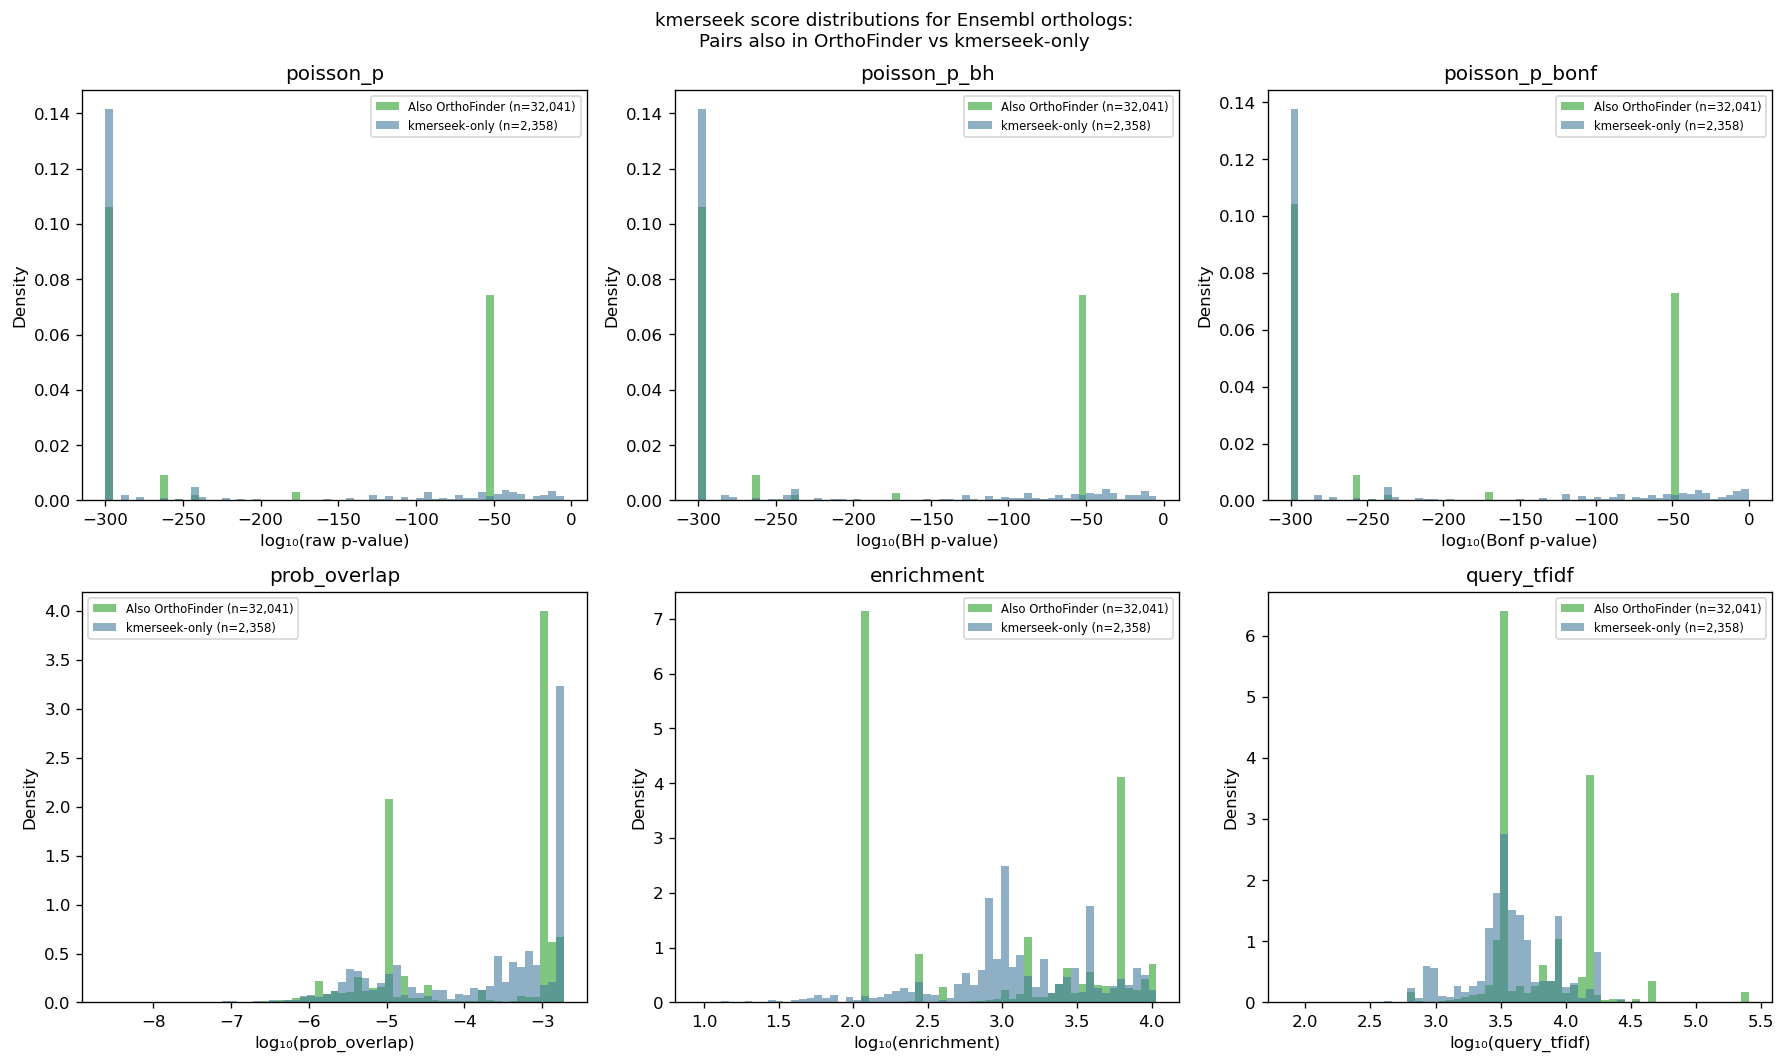

In [15]:
# Among Ensembl orthologs: compare kmerseek scores for those also in OrthoFinder vs those not
orth_only = df[df["is_ortholog"]].copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flat

metrics_dist = [
    ("poisson_p", True, "log₁₀(raw p-value)"),
    ("poisson_p_bh", True, "log₁₀(BH p-value)"),
    ("poisson_p_bonf", True, "log₁₀(Bonf p-value)"),
    ("prob_overlap", True, "log₁₀(prob_overlap)"),
    ("enrichment", True, "log₁₀(enrichment)"),
    ("query_tfidf", True, "log₁₀(query_tfidf)"),
]

for ax, (col, take_log, xlabel) in zip(axes, metrics_dist):
    vals_agree = orth_only.loc[orth_only["is_orthofinder"], col].clip(lower=1e-300)
    vals_only = orth_only.loc[~orth_only["is_orthofinder"], col].clip(lower=1e-300)

    if take_log:
        vals_agree = np.log10(vals_agree)
        vals_only = np.log10(vals_only)

    bins = np.linspace(
        min(vals_agree.min(), vals_only.min()),
        max(vals_agree.quantile(0.99), vals_only.quantile(0.99)),
        60,
    )
    ax.hist(
        vals_agree,
        bins=bins,
        density=True,
        alpha=0.6,
        color="#2ca02c",
        label=f"Also OrthoFinder (n={len(vals_agree):,})",
    )
    ax.hist(
        vals_only,
        bins=bins,
        density=True,
        alpha=0.6,
        color="#457b9d",
        label=f"kmerseek-only (n={len(vals_only):,})",
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(col)
    ax.legend(fontsize=7)

fig.suptitle(
    "kmerseek score distributions for Ensembl orthologs:\n"
    "Pairs also in OrthoFinder vs kmerseek-only",
    fontsize=11,
)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_score_dists.hp.k{KSIZE}.png", dpi=150)
plt.show()

## 8. Precision-Recall at fixed thresholds: heatmap summary

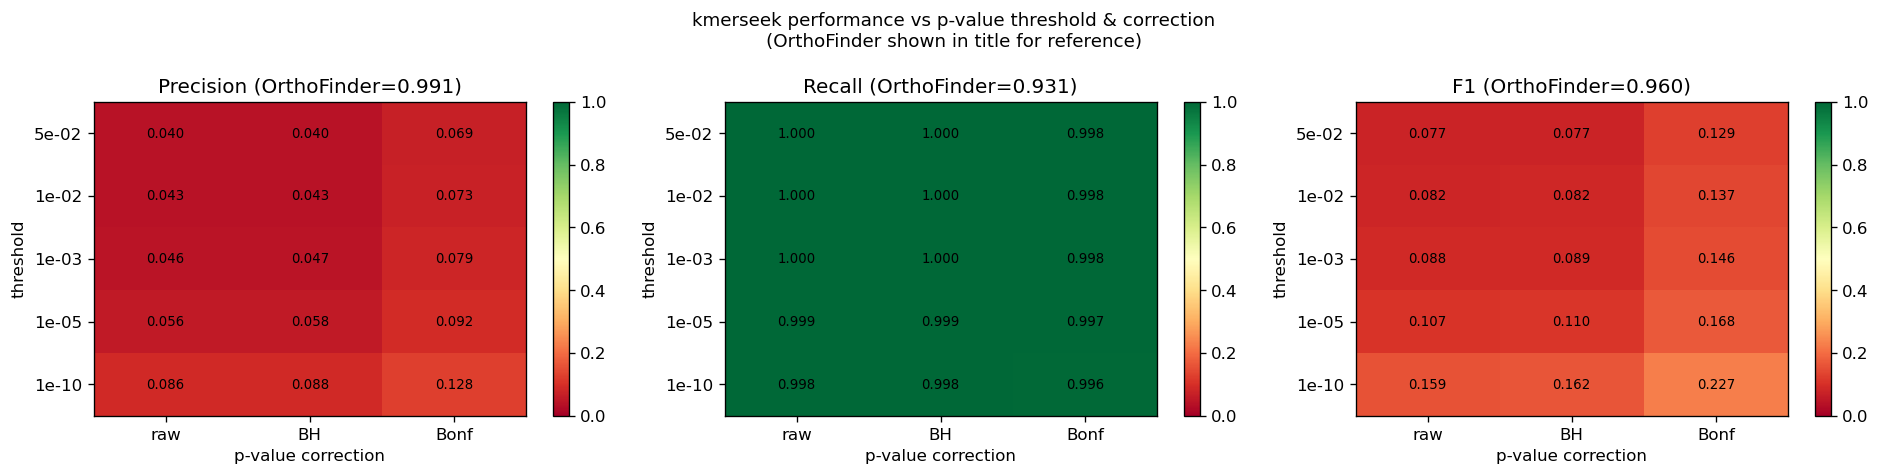

In [16]:
fixed_thresholds = [0.05, 0.01, 1e-3, 1e-5, 1e-10]
corrections = [
    ("raw", "poisson_p"),
    ("BH", "poisson_p_bh"),
    ("Bonf", "poisson_p_bonf"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for metric_name, (ax_idx, stat) in itertools.product(
    ["f1", "precision", "recall"], enumerate(["f1", "precision", "recall"])
):
    pass

# Build a table: rows = threshold, cols = (correction, metric)
stat_names = ["precision", "recall", "f1"]

for ax, stat in zip(axes, stat_names):
    mat = np.zeros((len(fixed_thresholds), len(corrections)))
    for j, (cname, col) in enumerate(corrections):
        for i, thr in enumerate(fixed_thresholds):
            s = confusion_stats(y_true, df[col] < thr)
            mat[i, j] = s[stat]

    im = ax.imshow(mat, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn")

    # Add OrthoFinder reference column as annotation
    of_val = of_stats[stat]
    for i in range(len(fixed_thresholds)):
        for j in range(len(corrections)):
            ax.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center", fontsize=8)

    ax.set_xticks(range(len(corrections)))
    ax.set_xticklabels([c for c, _ in corrections])
    ax.set_yticks(range(len(fixed_thresholds)))
    ax.set_yticklabels([f"{t:.0e}" for t in fixed_thresholds])
    ax.set_xlabel("p-value correction")
    ax.set_ylabel("threshold")
    ax.set_title(f"{stat.capitalize()} (OrthoFinder={of_val:.3f})")
    plt.colorbar(im, ax=ax)

fig.suptitle(
    "kmerseek performance vs p-value threshold & correction\n(OrthoFinder shown in title for reference)",
    fontsize=11,
)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_heatmap.hp.k{KSIZE}.png", dpi=150)
plt.show()

## 9. Examples: OrthoFinder-only vs kmerseek-only orthologs

In [17]:
# Use Bonferroni p < 0.05 as the representative kmerseek threshold
km_pred = df["poisson_p_bonf"] < ALPHA

# OrthoFinder-only Ensembl orthologs: OrthoFinder says yes, kmerseek Bonf says no, Ensembl says yes
of_only_true = df[of_pred & ~km_pred & y_true]
# kmerseek-only Ensembl orthologs: kmerseek Bonf says yes, OrthoFinder says no, Ensembl says yes
km_only_true = df[km_pred & ~of_pred & y_true]

print(
    f"Ensembl orthologs found by OrthoFinder but missed by kmerseek Bonf<0.05: {len(of_only_true):,}"
)
print(
    f"Ensembl orthologs found by kmerseek Bonf<0.05 but missed by OrthoFinder: {len(km_only_true):,}"
)

Ensembl orthologs found by OrthoFinder but missed by kmerseek Bonf<0.05: 26
Ensembl orthologs found by kmerseek Bonf<0.05 but missed by OrthoFinder: 2,324


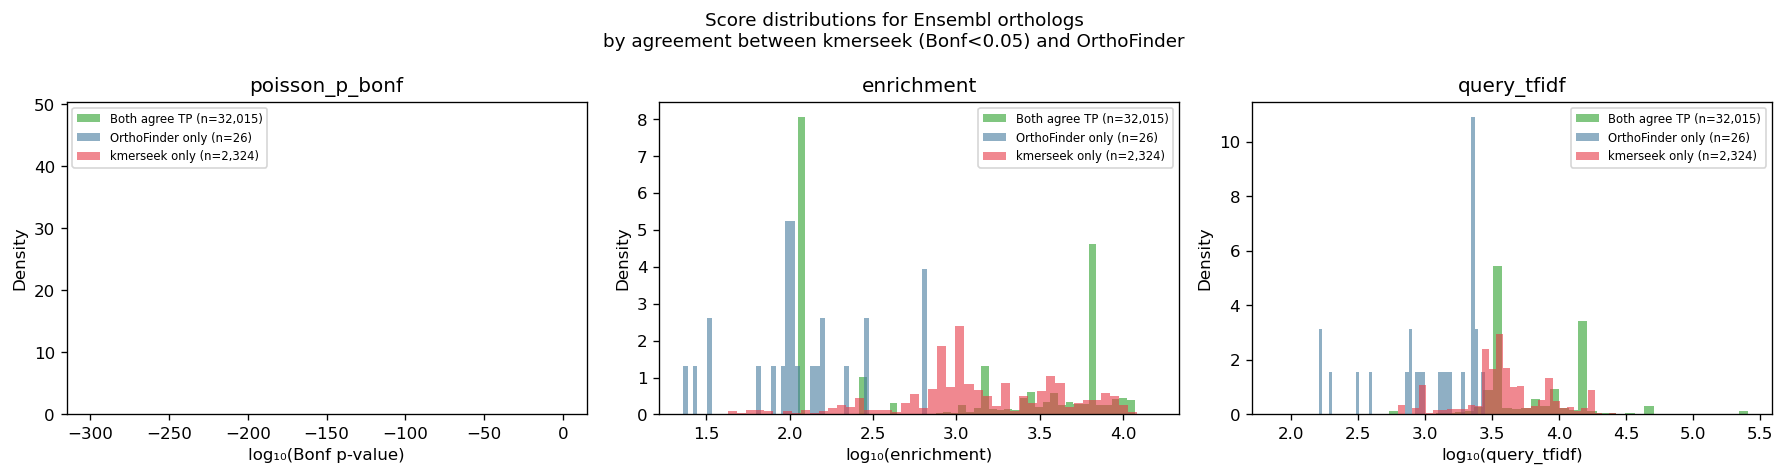

In [18]:
# Score distributions for the three agreement categories (Ensembl orthologs only)
agree_tp = df[km_pred & of_pred & y_true]  # both agree it's an ortholog
of_only_t = df[~km_pred & of_pred & y_true]  # OF only
km_only_t = df[km_pred & ~of_pred & y_true]  # kmerseek only

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, xlabel in [
    (axes[0], "poisson_p_bonf", "log₁₀(Bonf p-value)"),
    (axes[1], "enrichment", "log₁₀(enrichment)"),
    (axes[2], "query_tfidf", "log₁₀(query_tfidf)"),
]:
    for label, subset, color in [
        ("Both agree TP", agree_tp, "#2ca02c"),
        ("OrthoFinder only", of_only_t, "#457b9d"),
        ("kmerseek only", km_only_t, "#e63946"),
    ]:
        vals = np.log10(subset[col].clip(lower=1e-300))
        ax.hist(
            vals,
            bins=50,
            density=True,
            alpha=0.6,
            color=color,
            label=f"{label} (n={len(subset):,})",
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.set_title(col)

fig.suptitle(
    "Score distributions for Ensembl orthologs\nby agreement between kmerseek (Bonf<0.05) and OrthoFinder",
    fontsize=11,
)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_agreement_dists.hp.k{KSIZE}.png", dpi=150)
plt.show()

## 11. All kmerseek metrics vs OrthoFinder: threshold sweep + best-F1 summary

In [19]:
all_metrics = [
    # (label, scores, direction)  direction=+1 means higher=more likely ortholog
    ("poisson_p Bonf", df["poisson_p_bonf"], -1),
    ("poisson_p BH", df["poisson_p_bh"], -1),
    ("poisson_p raw", df["poisson_p"], -1),
    ("prob_overlap", df["prob_overlap"], +1),
    ("enrichment", df["enrichment"], +1),
    ("query_tfidf", df["query_tfidf"], +1),
    ("containment", df["containment"], +1),
    ("n_intersecting", df["n_intersecting_hashes"], +1),
]


def sweep_metric(scores, direction, n_thr=300):
    lo, hi = scores.quantile(0.001), scores.quantile(0.999)
    thrs = np.linspace(lo, hi, n_thr)
    records = []
    for thr in thrs:
        pred = (scores >= thr) if direction > 0 else (scores <= thr)
        s = confusion_stats(y_true, pred)
        s["threshold"] = thr
        records.append(s)
    return pd.DataFrame(records)


# Sweep each metric
sweeps = {
    label: sweep_metric(scores, direction) for label, scores, direction in all_metrics
}

# Best F1 summary
best_rows = []
for label, sw in sweeps.items():
    best = sw.loc[sw["f1"].idxmax()]
    best_rows.append(
        dict(
            metric=label,
            best_f1=best["f1"],
            precision_at_best_f1=best["precision"],
            recall_at_best_f1=best["recall"],
            n_predicted_at_best_f1=best["n_predicted"],
            threshold=best["threshold"],
        )
    )
best_df = pd.DataFrame(best_rows).set_index("metric")

# Add OrthoFinder row
best_df.loc["OrthoFinder"] = dict(
    best_f1=of_stats["f1"],
    precision_at_best_f1=of_stats["precision"],
    recall_at_best_f1=of_stats["recall"],
    n_predicted_at_best_f1=of_stats["n_predicted"],
    threshold=float("nan"),
)

display(best_df.sort_values("best_f1", ascending=False).round(3))

,best_f1,precision_at_best_f1,recall_at_best_f1,n_predicted_at_best_f1,threshold
metric,,,,,
OrthoFinder,0.960,0.991,0.931,32320.0,NaN
containment,0.715,0.919,0.585,21911.0,0.221
n_intersecting,0.712,0.833,0.622,25708.0,70.803
enrichment,0.690,0.902,0.559,21315.0,1042.867
poisson_p Bonf,0.666,0.868,0.540,21422.0,0.000
poisson_p BH,0.666,0.868,0.540,21422.0,0.000
poisson_p raw,0.666,0.868,0.540,21422.0,0.000
prob_overlap,0.210,0.132,0.511,133306.0,0.001
query_tfidf,0.165,0.122,0.254,71891.0,14897.941


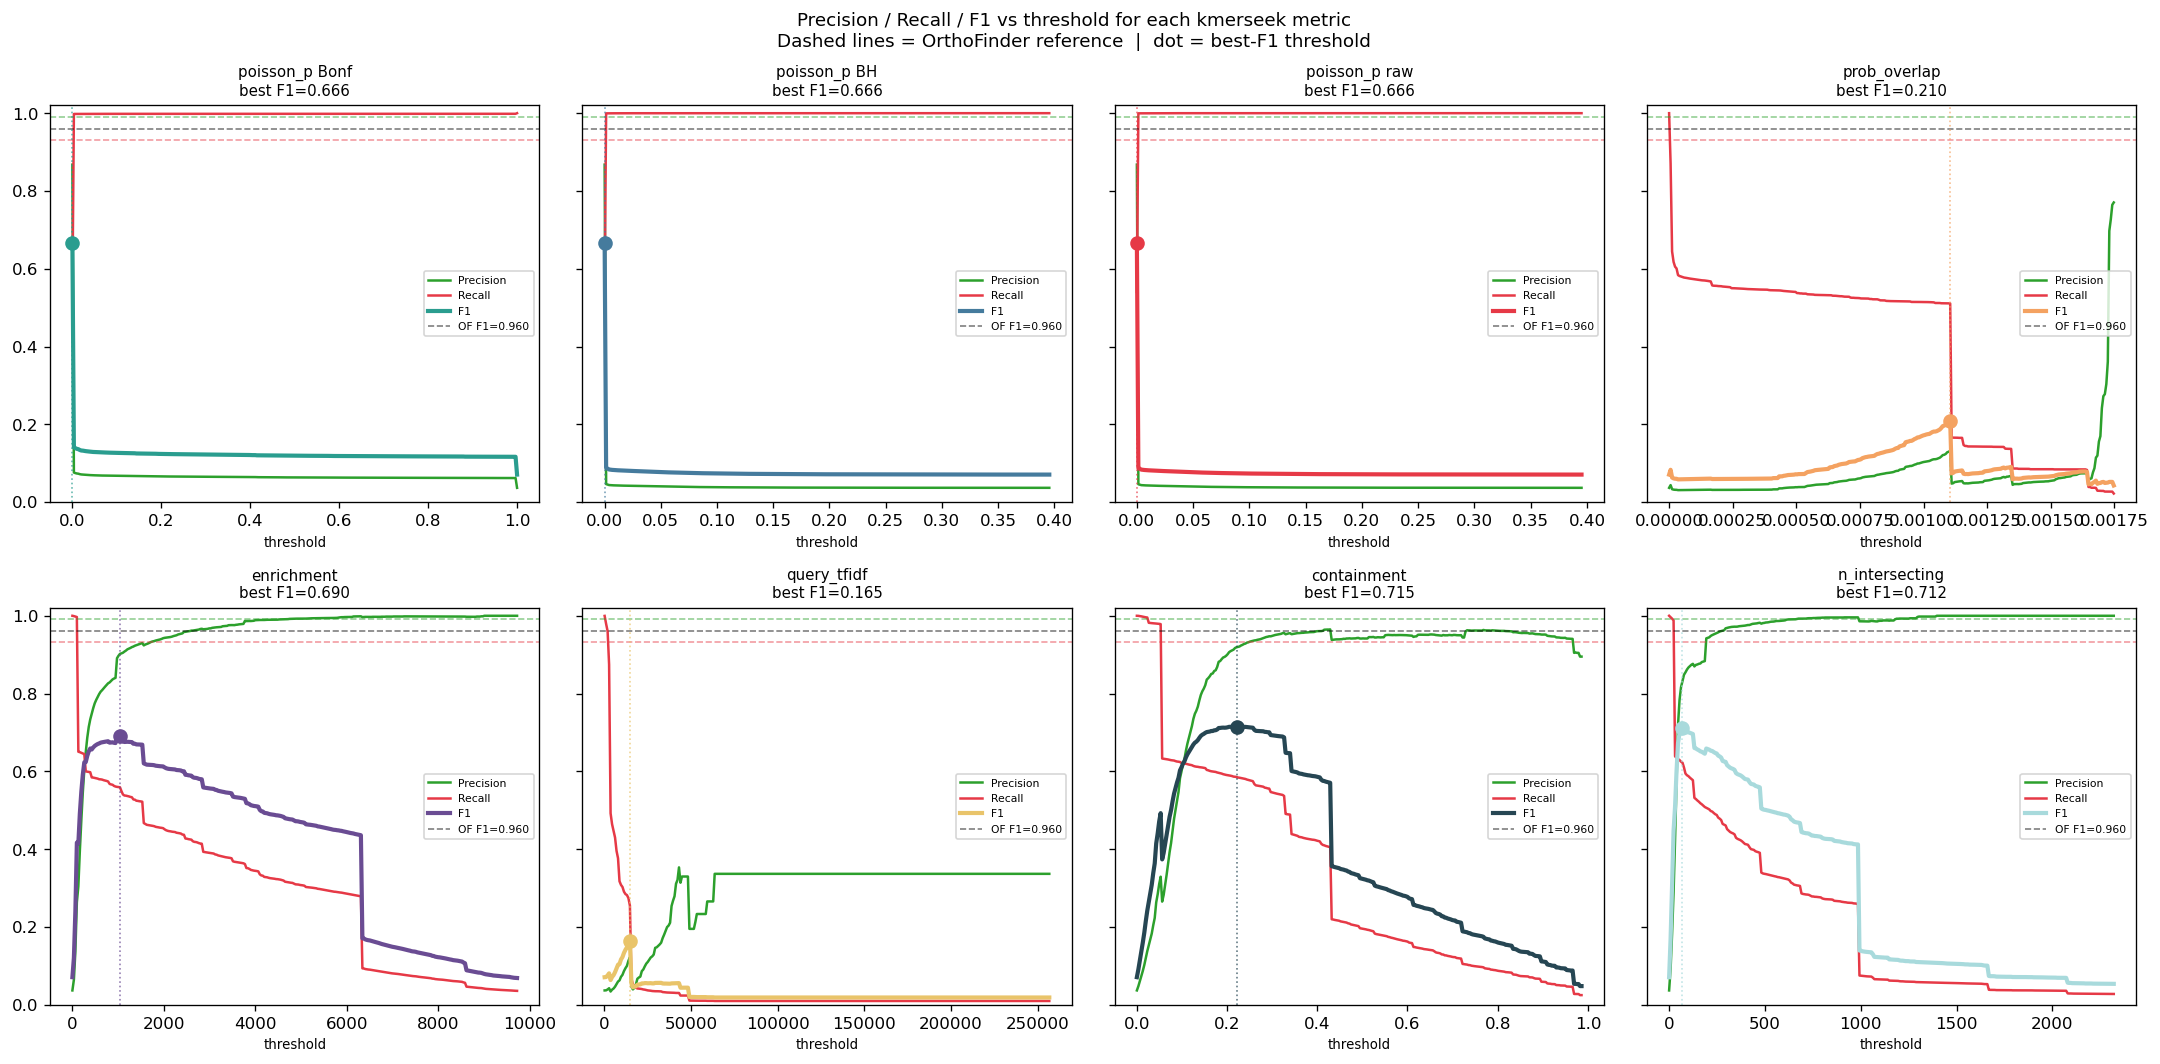

In [20]:
colors_map = {
    "poisson_p Bonf": "#2a9d8f",
    "poisson_p BH": "#457b9d",
    "poisson_p raw": "#e63946",
    "prob_overlap": "#f4a261",
    "enrichment": "#6a4c93",
    "query_tfidf": "#e9c46a",
    "containment": "#264653",
    "n_intersecting": "#a8dadc",
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=True)
axes = axes.flat

for ax, (label, sw) in zip(axes, sweeps.items()):
    color = colors_map[label]
    ax.plot(
        sw["threshold"], sw["precision"], color="#2ca02c", lw=1.5, label="Precision"
    )
    ax.plot(sw["threshold"], sw["recall"], color="#e63946", lw=1.5, label="Recall")
    ax.plot(sw["threshold"], sw["f1"], color=color, lw=2.5, label="F1", zorder=3)

    # OrthoFinder reference dashes
    ax.axhline(of_stats["precision"], ls="--", color="#2ca02c", lw=1, alpha=0.5)
    ax.axhline(of_stats["recall"], ls="--", color="#e63946", lw=1, alpha=0.5)
    ax.axhline(
        of_stats["f1"],
        ls="--",
        color="k",
        lw=1,
        alpha=0.5,
        label=f"OF F1={of_stats['f1']:.3f}",
    )

    # Mark best-F1 threshold
    best_idx = sw["f1"].idxmax()
    ax.axvline(sw.loc[best_idx, "threshold"], color=color, lw=1, ls=":", alpha=0.7)
    ax.scatter(
        sw.loc[best_idx, "threshold"],
        sw.loc[best_idx, "f1"],
        s=60,
        color=color,
        zorder=5,
    )

    ax.set_title(f'{label}\nbest F1={sw["f1"].max():.3f}', fontsize=9)
    ax.set_xlabel("threshold", fontsize=8)
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=6.5)

fig.suptitle(
    "Precision / Recall / F1 vs threshold for each kmerseek metric\n"
    "Dashed lines = OrthoFinder reference  |  dot = best-F1 threshold",
    fontsize=11,
)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_all_metrics_sweep.hp.k{KSIZE}.png", dpi=150)
plt.show()

## 12. Summary table: top-line comparison

In [21]:
# Recompute on full 5% sample (not just orthologs), display full summary
summary_styled = summary[
    ["n_predicted", "TP", "FP", "FN", "precision", "recall", "f1"]
].copy()
summary_styled.columns = ["N predicted", "TP", "FP", "FN", "Precision", "Recall", "F1"]

# Highlight best in each column
display(
    summary_styled.style.format(
        {
            "N predicted": "{:,.0f}",
            "TP": "{:,.0f}",
            "FP": "{:,.0f}",
            "FN": "{:,.0f}",
            "Precision": "{:.3f}",
            "Recall": "{:.3f}",
            "F1": "{:.3f}",
        }
    )
    .highlight_max(subset=["Precision", "Recall", "F1"], color="lightgreen")
    .highlight_min(subset=["FP"], color="lightblue")
    .set_caption(
        f"kmerseek k={KSIZE} HP encoding vs OrthoFinder (5% sample, ground truth = Ensembl)"
    )
)

,N predicted,TP,FP,FN,Precision,Recall,F1
method,,,,,,,
OrthoFinder,"32,320","32,041",279,"2,358",0.991,0.931,0.960
kmerseek raw p<0.05,"863,692","34,397","829,295",2,0.040,1.000,0.077
kmerseek BH p<0.05,"858,286","34,397","823,889",2,0.040,1.000,0.077
kmerseek Bonf p<0.05,"499,074","34,339","464,735",60,0.069,0.998,0.129
kmerseek raw p<1e-5,"608,594","34,364","574,230",35,0.056,0.999,0.107
kmerseek BH p<1e-5,"589,848","34,364","555,484",35,0.058,0.999,0.110
kmerseek Bonf p<1e-5,"373,225","34,312","338,913",87,0.092,0.997,0.168


## 13. Are kmerseek false positives biologically meaningful?

kmerseek FPs = pairs predicted as orthologs (Bonf p<0.05) that Ensembl doesn't call orthologs.
Hypothesis: these could be *paralogs* or *same gene family* — biologically related but not strictly 1-to-1 orthologs.

In [22]:
import re


# Gene name is field 6 (0-indexed) of the pipe-delimited protein ID
def extract_gene(name):
    parts = name.split("|")
    return parts[6] if len(parts) > 6 else parts[0]


def gene_family_prefix(gene, n=3):
    """Extract alphabetic prefix (gene family root), e.g. 'OR4F5' -> 'OR'."""
    m = re.match(r"^([A-Za-z]+)", gene)
    return m.group(1) if m else gene


df["human_gene_name"] = df["query_name"].apply(extract_gene)
df["mouse_gene_name"] = df["target_name"].apply(extract_gene)
df["human_family"] = df["human_gene_name"].apply(gene_family_prefix)
df["mouse_family"] = df["mouse_gene_name"].apply(gene_family_prefix)
df["same_family"] = df["human_family"] == df["mouse_family"]

# Define FPs and TPs using Bonferroni threshold
km_bonf = df["poisson_p_bonf"] < ALPHA
fp = df[km_bonf & ~y_true]  # predicted ortholog, not Ensembl ortholog
tp = df[km_bonf & y_true]  # predicted ortholog, is  Ensembl ortholog
fn = df[~km_bonf & y_true]  # missed Ensembl ortholog

print(f"FP: {len(fp):,}  |  TP: {len(tp):,}  |  FN: {len(fn):,}")
print(
    f"\nSame gene family in FPs: {fp['same_family'].mean():.1%}  ({fp['same_family'].sum():,}/{len(fp):,})"
)
print(
    f"Same gene family in TPs: {tp['same_family'].mean():.1%}  ({tp['same_family'].sum():,}/{len(tp):,})"
)

FP: 464,735  |  TP: 34,339  |  FN: 60

Same gene family in FPs: 0.0%  (76/464,735)
Same gene family in TPs: 0.2%  (64/34,339)


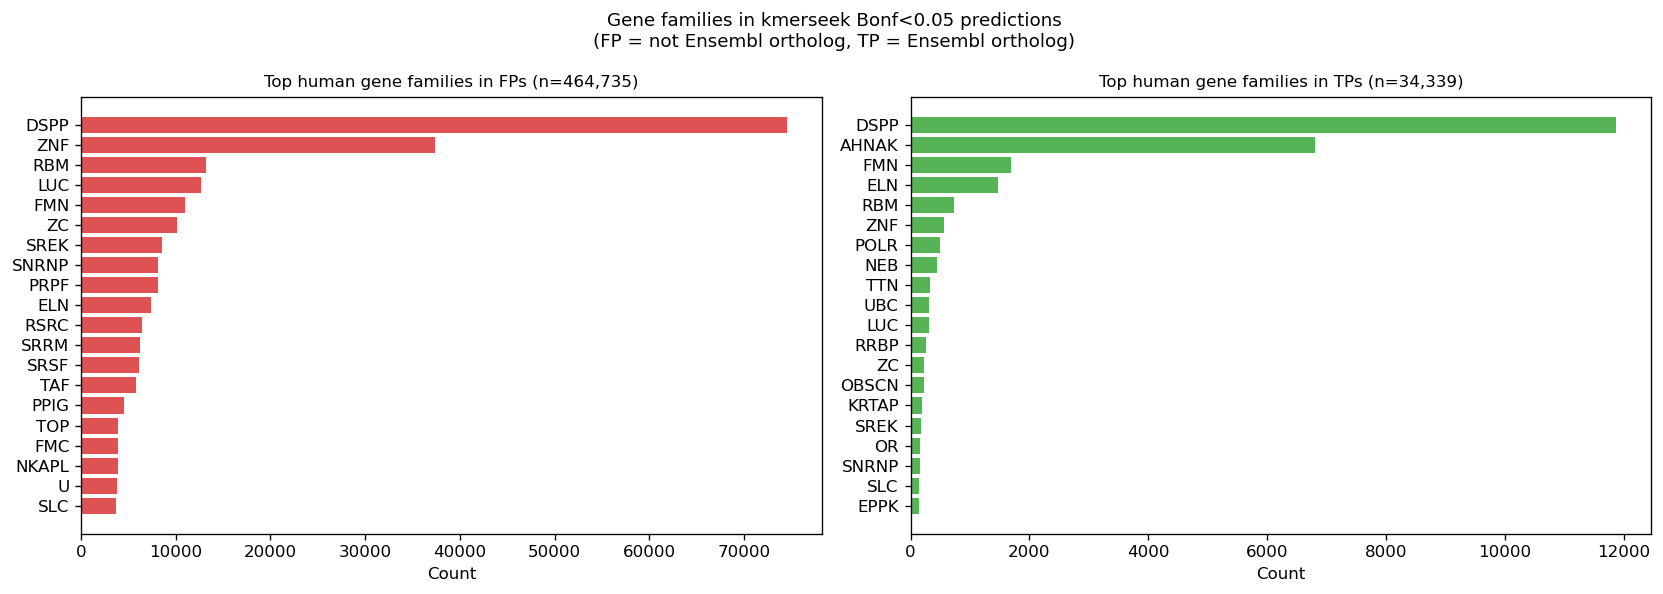

In [23]:
# Top gene families in FPs vs TPs
def top_families(subset, col="human_family", n=20):
    return subset[col].value_counts().head(n)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset, title, color in [
    (axes[0], fp, f"Top human gene families in FPs (n={len(fp):,})", "#d62728"),
    (axes[1], tp, f"Top human gene families in TPs (n={len(tp):,})", "#2ca02c"),
]:
    counts = top_families(subset)
    ax.barh(counts.index[::-1], counts.values[::-1], color=color, alpha=0.8)
    ax.set_xlabel("Count")
    ax.set_title(title, fontsize=10)

fig.suptitle(
    "Gene families in kmerseek Bonf<0.05 predictions\n(FP = not Ensembl ortholog, TP = Ensembl ortholog)",
    fontsize=11,
)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_fp_gene_families.hp.k{KSIZE}.png", dpi=150)
plt.show()

In [24]:
# Load OrthoFinder orthogroups to check if FP pairs are paralogs (same orthogroup)
print("Loading OrthoFinder orthogroups...")
ORTHOGROUPS_TSV = ORTHOFINDER_DIR / "Orthogroups" / "Orthogroups.tsv"

prot_to_og = {}  # protein_id -> orthogroup
with open(ORTHOGROUPS_TSV) as f:
    reader = csv.DictReader(f, delimiter="\t")
    for row in reader:
        og = row["Orthogroup"]
        for col in ["gencode.v49.pc_translations", "gencode.vM38.pc_translations"]:
            for prot in row[col].split(","):
                pid = prot.strip().split("|")[0]
                if pid:
                    prot_to_og[pid] = og

print(f"Proteins mapped to orthogroups: {len(prot_to_og):,}")


# For each pair, check if both proteins share the same orthogroup
def same_orthogroup(h_ids, m_ids):
    og_h = [prot_to_og.get(h) for h in h_ids]
    og_m = [prot_to_og.get(m) for m in m_ids]
    return [(oh is not None and oh == om) for oh, om in zip(og_h, og_m)]


df["same_orthogroup"] = same_orthogroup(df["query_prot_id"], df["target_prot_id"])

# Refresh subsets so new column is included
fp = df[km_bonf & ~y_true]
tp = df[km_bonf & y_true]
fn = df[~km_bonf & y_true]

print(f"\nSame OrthoFinder orthogroup:")
print(
    f"  FPs: {fp['same_orthogroup'].mean():.1%}  ({fp['same_orthogroup'].sum():,}/{len(fp):,})"
)
print(
    f"  TPs: {tp['same_orthogroup'].mean():.1%}  ({tp['same_orthogroup'].sum():,}/{len(tp):,})"
)
print(
    f"  FNs: {fn['same_orthogroup'].mean():.1%}  ({fn['same_orthogroup'].sum():,}/{len(fn):,})"
)
print(
    f"  all non-orthologs (background): "
    f"{df.loc[~y_true, 'same_orthogroup'].mean():.1%}"
)

Loading OrthoFinder orthogroups...
Proteins mapped to orthogroups: 262,365

Same OrthoFinder orthogroup:
  FPs: 0.1%  (273/464,735)
  TPs: 93.2%  (32,015/34,339)
  FNs: 43.3%  (26/60)
  all non-orthologs (background): 0.0%


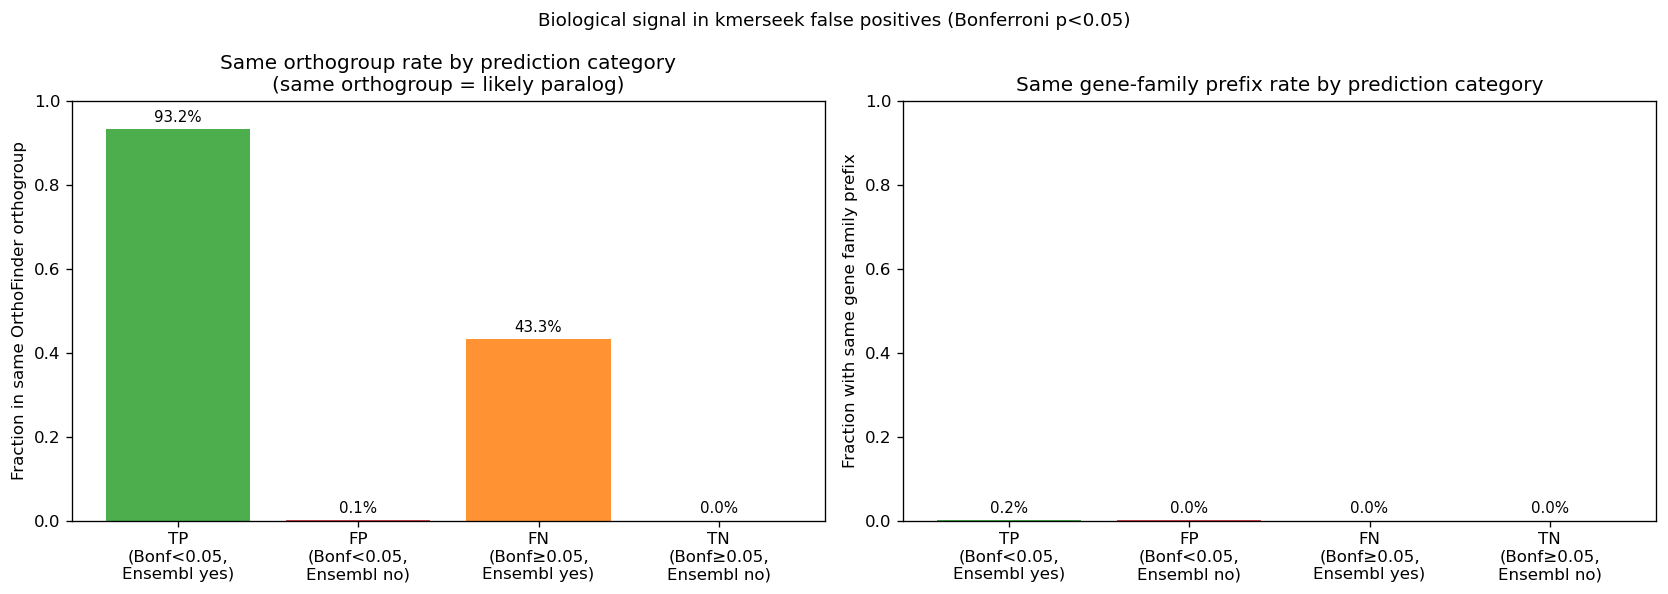

In [25]:
# Summary bar: same-orthogroup rate across prediction categories
categories = {
    "TP\n(Bonf<0.05,\nEnsembl yes)": tp,
    "FP\n(Bonf<0.05,\nEnsembl no)": fp,
    "FN\n(Bonf≥0.05,\nEnsembl yes)": fn,
    "TN\n(Bonf≥0.05,\nEnsembl no)": df[~km_bonf & ~y_true],
}
colors_cat = ["#2ca02c", "#d62728", "#ff7f0e", "#aec7e8"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: same-orthogroup rate
ax = axes[0]
rates = [sub["same_orthogroup"].mean() for sub in categories.values()]
labels = list(categories.keys())
bars = ax.bar(labels, rates, color=colors_cat, alpha=0.85)
ax.set_ylabel("Fraction in same OrthoFinder orthogroup")
ax.set_title(
    "Same orthogroup rate by prediction category\n(same orthogroup = likely paralog)"
)
ax.set_ylim(0, 1)
for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.01,
        f"{rate:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Right: same-family rate
ax = axes[1]
rates2 = [sub["same_family"].mean() for sub in categories.values()]
bars2 = ax.bar(labels, rates2, color=colors_cat, alpha=0.85)
ax.set_ylabel("Fraction with same gene family prefix")
ax.set_title("Same gene-family prefix rate by prediction category")
ax.set_ylim(0, 1)
for bar, rate in zip(bars2, rates2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.01,
        f"{rate:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.suptitle(
    "Biological signal in kmerseek false positives (Bonferroni p<0.05)", fontsize=11
)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_fp_biological_signal.hp.k{KSIZE}.png", dpi=150)
plt.show()

## 14. How do other kmerseek metrics score on FPs vs TPs?

If FPs have high scores across *all* metrics, they may be real homologs missing from Ensembl.
If FPs are only high in Poisson p but low in containment/enrichment/tfidf, the signal is likely spurious (e.g. shared low-complexity sequence).

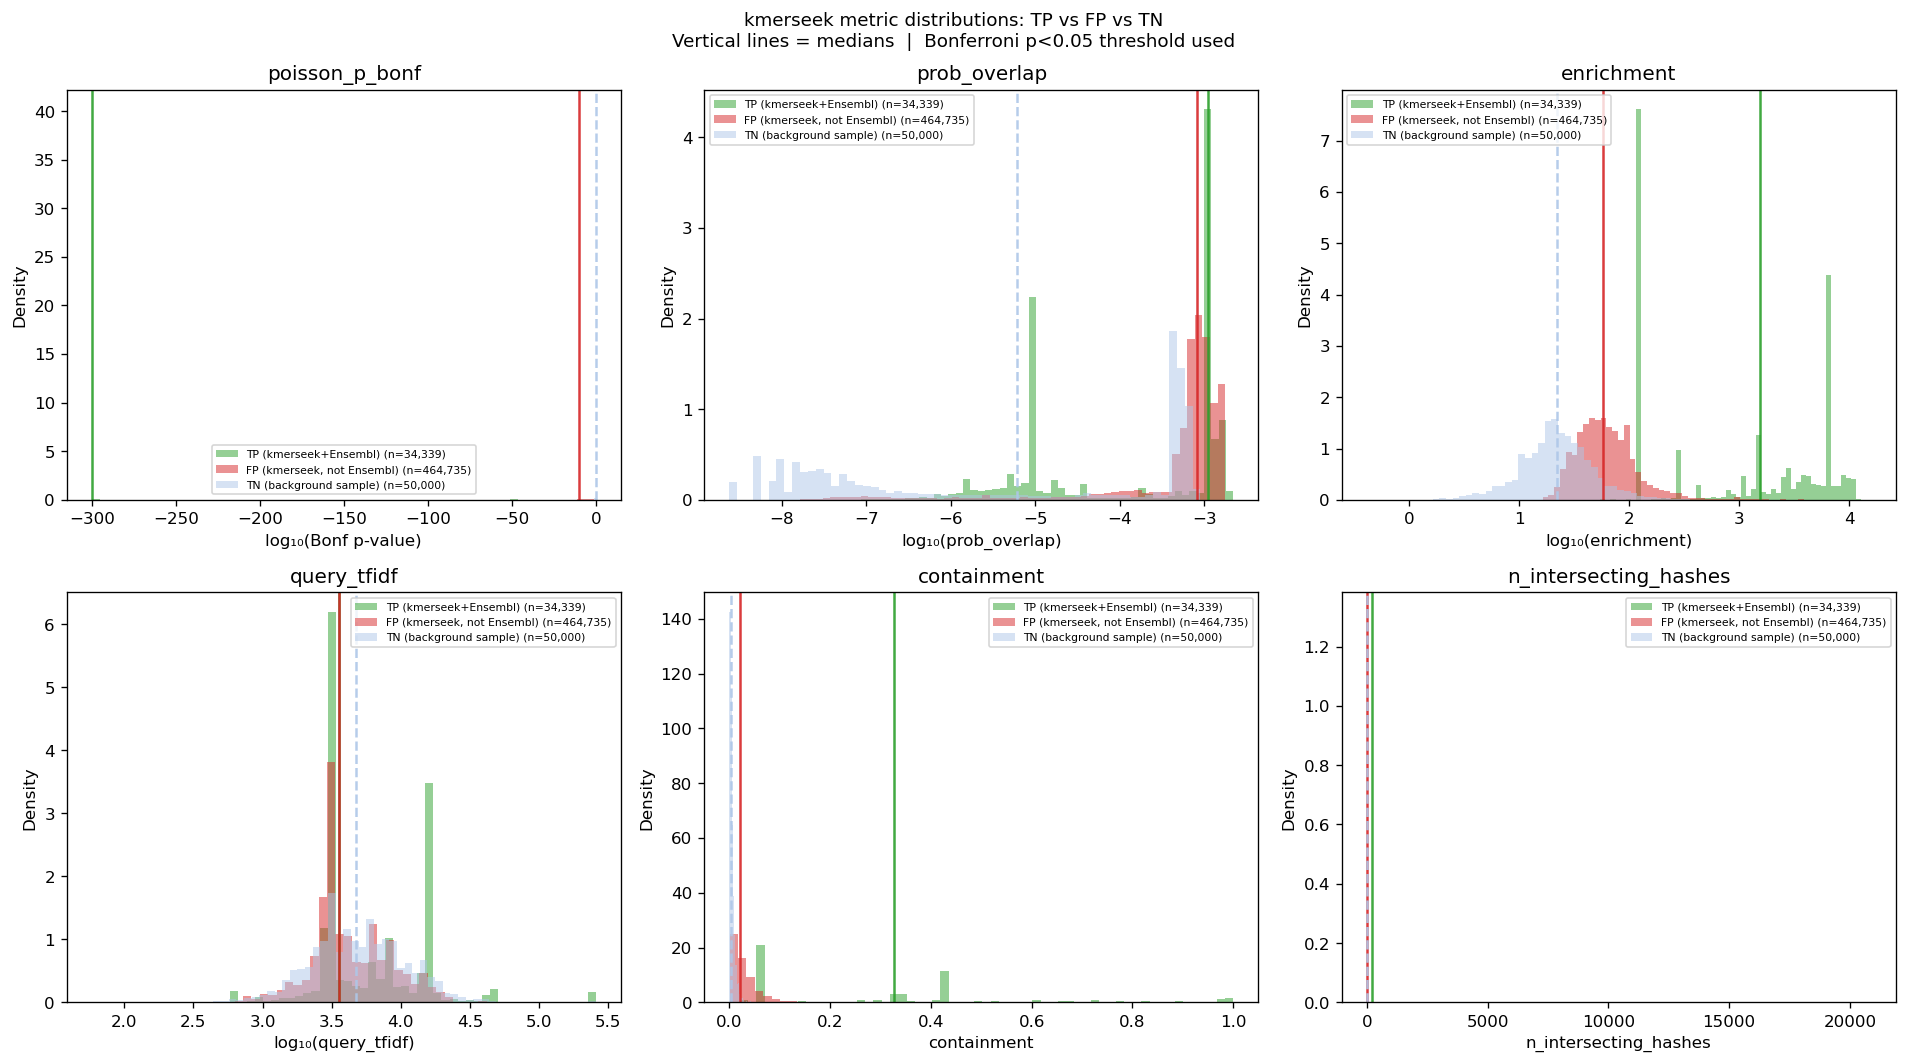

In [26]:
score_metrics = [
    ("poisson_p_bonf", True, "log₁₀(Bonf p-value)", -1),
    ("prob_overlap", True, "log₁₀(prob_overlap)", +1),
    ("enrichment", True, "log₁₀(enrichment)", +1),
    ("query_tfidf", True, "log₁₀(query_tfidf)", +1),
    ("containment", False, "containment", +1),
    ("n_intersecting_hashes", False, "n_intersecting_hashes", +1),
]

# Three groups: TP, FP, TN (skip FN — only 60 points)
groups = [
    ("TP (kmerseek+Ensembl)", tp, "#2ca02c", "-"),
    ("FP (kmerseek, not Ensembl)", fp, "#d62728", "-"),
    (
        "TN (background sample)",
        df[~km_bonf & ~y_true].sample(
            min(50000, (~km_bonf & ~y_true).sum()), random_state=42
        ),
        "#aec7e8",
        "--",
    ),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flat

for ax, (col, take_log, xlabel, direction) in zip(axes, score_metrics):
    for label, subset, color, ls in groups:
        vals = subset[col].clip(lower=1e-300)
        if take_log:
            vals = np.log10(vals)
        ax.hist(
            vals,
            bins=60,
            density=True,
            alpha=0.5,
            color=color,
            label=f"{label} (n={len(subset):,})",
            histtype="stepfilled",
        )
        ax.axvline(vals.median(), color=color, lw=1.5, ls=ls, alpha=0.9)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(col)
    ax.legend(fontsize=6.5)

fig.suptitle(
    "kmerseek metric distributions: TP vs FP vs TN\n"
    "Vertical lines = medians  |  Bonferroni p<0.05 threshold used",
    fontsize=11,
)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_fp_metric_dists.hp.k{KSIZE}.png", dpi=150)
plt.show()

In [27]:
# Median score table: TP vs FP vs TN
medians = {}
for col, take_log, xlabel, _ in score_metrics:
    row = {}
    for label, subset, *_ in groups:
        vals = subset[col].clip(lower=1e-300)
        if take_log:
            vals = np.log10(vals)
        row[label] = vals.median()
    medians[xlabel] = row

med_df = pd.DataFrame(medians).T
print("Median values per group (log-transformed where noted):")
display(med_df.round(3))

Median values per group (log-transformed where noted):


,TP (kmerseek+Ensembl),"FP (kmerseek, not Ensembl)",TN (background sample)
log₁₀(Bonf p-value),-300.000,-10.164,0.000
log₁₀(prob_overlap),-2.956,-3.082,-5.216
log₁₀(enrichment),3.192,1.762,1.339
log₁₀(query_tfidf),3.556,3.555,3.674
containment,0.327,0.021,0.004
n_intersecting_hashes,214.000,12.000,3.000


In [28]:
# For each metric: what fraction of FPs exceed the TP median threshold?
# i.e. do FPs "look like" TPs by other metrics?
print("Fraction of FPs that exceed the TP median for each metric:\n")
rows = []
for col, take_log, xlabel, direction in score_metrics:
    tp_vals = tp[col].clip(lower=1e-300)
    fp_vals = fp[col].clip(lower=1e-300)
    if take_log:
        tp_vals = np.log10(tp_vals)
        fp_vals = np.log10(fp_vals)

    tp_med = tp_vals.median()
    if direction > 0:  # higher = better
        frac_fp_above = (fp_vals > tp_med).mean()
    else:  # lower = better (p-values)
        frac_fp_above = (fp_vals < tp_med).mean()

    rows.append(
        dict(
            metric=xlabel,
            TP_median=round(tp_med, 3),
            frac_FP_exceeds_TP_median=round(frac_fp_above, 3),
        )
    )
    print(
        f"  {xlabel:30s}  TP median={tp_med:8.3f}  "
        f"FP > TP median: {frac_fp_above:.1%}"
    )

exceed_df = pd.DataFrame(rows).set_index("metric")
display(exceed_df)

Fraction of FPs that exceed the TP median for each metric:

  log₁₀(Bonf p-value)             TP median=-300.000  FP > TP median: 0.0%
  log₁₀(prob_overlap)             TP median=  -2.956  FP > TP median: 24.7%
  log₁₀(enrichment)               TP median=   3.192  FP > TP median: 0.3%
  log₁₀(query_tfidf)              TP median=   3.556  FP > TP median: 48.9%
  containment                     TP median=   0.327  FP > TP median: 0.2%
  n_intersecting_hashes           TP median= 214.000  FP > TP median: 0.2%


,TP_median,frac_FP_exceeds_TP_median
metric,,
log₁₀(Bonf p-value),-300.000,0.000
log₁₀(prob_overlap),-2.956,0.247
log₁₀(enrichment),3.192,0.003
log₁₀(query_tfidf),3.556,0.489
containment,0.327,0.002
n_intersecting_hashes,214.000,0.002


## 15. Combined scores: containment × jaccard × enrichment

Load `jaccard`, create product scores, then compute ROC AUC and best-F1 using `precision_recall_curve` (no slow threshold loop).

In [29]:
# Re-read with same sample — indices will match, so align by index
df_extra = pd.read_csv(
    EVAL_TSV,
    sep="\t",
    usecols=["query_name", "target_name", "jaccard", "max_containment"],
).sample(frac=SAMPLE_FRAC, random_state=42)

# Both sampled identically → same index values; align directly
df["jaccard"] = df_extra["jaccard"].values
df["max_containment"] = df_extra["max_containment"].values

print(f"jaccard  null: {df['jaccard'].isna().sum()}")
print(f"jaccard range: {df['jaccard'].min():.4f} – {df['jaccard'].max():.4f}")
print(
    f"max_containment range: {df['max_containment'].min():.4f} – {df['max_containment'].max():.4f}"
)

jaccard  null: 0
jaccard range: 0.0000 – 0.9914
max_containment range: 0.0002 – 1.0000


In [30]:
c = df["containment"].clip(lower=1e-9)
j = df["jaccard"].clip(lower=1e-9)
e = df["enrichment"].clip(lower=1e-9)
mc = df["max_containment"].clip(lower=1e-9)

df["c_x_e"] = c * e
df["c_x_j"] = c * j
df["e_x_j"] = e * j
df["c_x_e_x_j"] = c * e * j
df["mc_x_e"] = mc * e
df["geomean_ce"] = np.sqrt(c * e)

# Refresh masks / subsets after adding new columns
km_bonf = df["poisson_p_bonf"] < ALPHA
y_true = df["is_ortholog"]
of_pred = df["is_orthofinder"]

print("Combined score medians (ortholog vs non-ortholog):")
for col in ["c_x_e", "c_x_j", "e_x_j", "c_x_e_x_j", "mc_x_e", "geomean_ce"]:
    med_t = df.loc[y_true, col].median()
    med_f = df.loc[~y_true, col].median()
    print(
        f"  {col:20s}  ortholog={med_t:.4g}  non-ortholog={med_f:.4g}  ratio={med_t/med_f:.1f}x"
    )

Combined score medians (ortholog vs non-ortholog):
  c_x_e                 ortholog=529.4  non-ortholog=0.3566  ratio=1484.6x
  c_x_j                 ortholog=0.05691  non-ortholog=3.797e-05  ratio=1499.0x
  e_x_j                 ortholog=321.4  non-ortholog=0.1563  ratio=2055.9x
  c_x_e_x_j             ortholog=109.5  non-ortholog=0.001435  ratio=76308.9x
  mc_x_e                ortholog=535.9  non-ortholog=0.5346  ratio=1002.3x
  geomean_ce            ortholog=23.01  non-ortholog=0.5972  ratio=38.5x


In [31]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

all_metrics_v2 = [
    (
        "poisson_p Bonf",
        -df["poisson_p_bonf"],
    ),
    (
        "containment",
        df["containment"],
    ),
    (
        "jaccard",
        df["jaccard"],
    ),
    (
        "max_containment",
        df["max_containment"],
    ),
    (
        "enrichment",
        df["enrichment"],
    ),
    (
        "n_intersecting",
        df["n_intersecting_hashes"],
    ),
    (
        "prob_overlap",
        df["prob_overlap"],
    ),
    (
        "query_tfidf",
        df["query_tfidf"],
    ),
    (
        "c × e",
        df["c_x_e"],
    ),
    (
        "c × j",
        df["c_x_j"],
    ),
    (
        "e × j",
        df["e_x_j"],
    ),
    (
        "c × e × j",
        df["c_x_e_x_j"],
    ),
    (
        "max_c × e",
        df["mc_x_e"],
    ),
    (
        "geomean(c, e)",
        df["geomean_ce"],
    ),
]

rows = []
for label, scores in all_metrics_v2:
    s = scores.values
    roc_auc = roc_auc_score(y_true, s)
    ap = average_precision_score(y_true, s)
    # Best F1 via precision_recall_curve (fast, exact)
    prec, rec, _ = precision_recall_curve(y_true, s)
    denom = prec + rec
    f1_arr = np.where(denom > 0, 2 * prec * rec / denom, 0)
    best_f1 = f1_arr.max()
    best_idx = f1_arr.argmax()
    rows.append(
        dict(
            metric=label,
            ROC_AUC=roc_auc,
            avg_precision=ap,
            best_F1=best_f1,
            precision_at_F1=prec[best_idx],
            recall_at_F1=rec[best_idx],
        )
    )

result_df = (
    pd.DataFrame(rows).set_index("metric").sort_values("ROC_AUC", ascending=False)
)

# Add OrthoFinder reference row
of_s = confusion_stats(y_true, of_pred)
result_df.loc["★ OrthoFinder"] = dict(
    ROC_AUC=float("nan"),
    avg_precision=float("nan"),
    best_F1=of_s["f1"],
    precision_at_F1=of_s["precision"],
    recall_at_F1=of_s["recall"],
)

display(result_df.round(4))

,ROC_AUC,avg_precision,best_F1,precision_at_F1,recall_at_F1
metric,,,,,
poisson_p Bonf,0.9832,0.7315,0.7182,0.8439,0.6251
e × j,0.9832,0.7830,0.7289,0.8828,0.6206
n_intersecting,0.9831,0.7871,0.7151,0.8436,0.6206
c × e × j,0.9805,0.7670,0.7298,0.9104,0.6089
jaccard,0.9784,0.7533,0.7222,0.8887,0.6082
c × j,0.9774,0.7505,0.7210,0.9169,0.5940
"geomean(c, e)",0.9757,0.7464,0.7268,0.8775,0.6202
c × e,0.9757,0.7464,0.7268,0.8775,0.6202
enrichment,0.9732,0.7315,0.6903,0.9022,0.5590


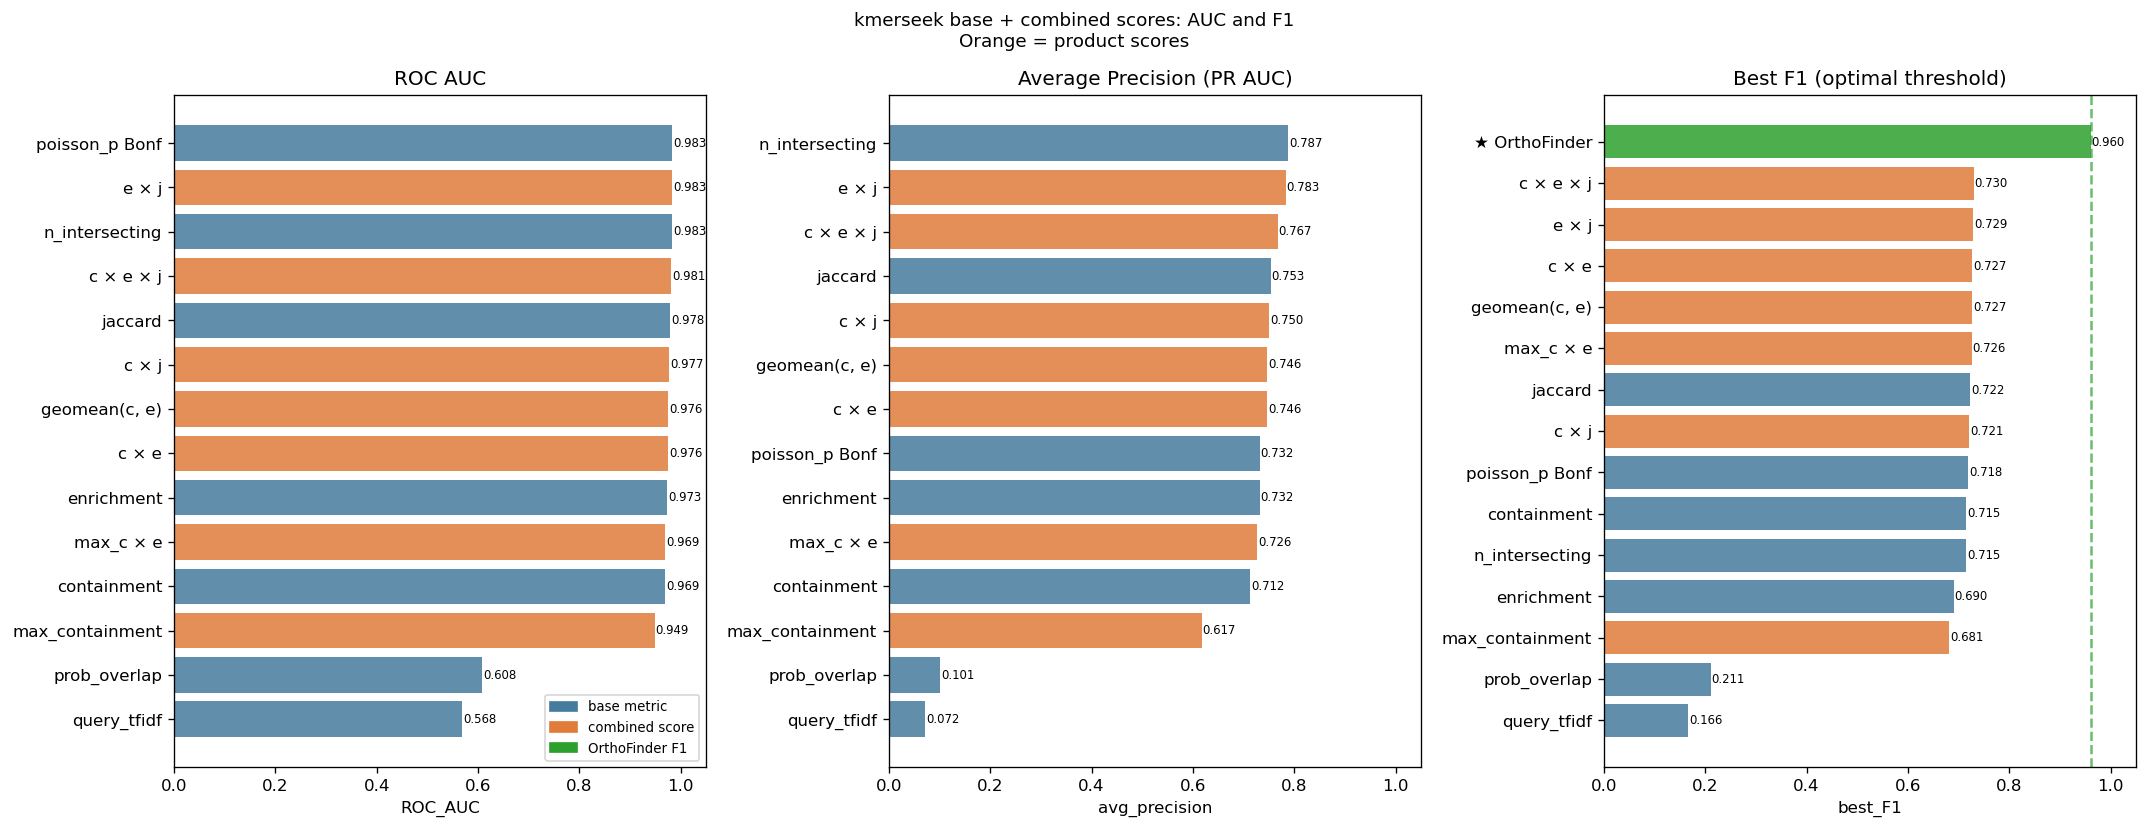

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))


def bar_color(label):
    if "OrthoFinder" in label:
        return "#2ca02c"
    if any(x in label for x in ["×", "geomean", "max_c"]):
        return "#e07b39"
    return "#457b9d"


for ax, col, title in [
    (axes[0], "ROC_AUC", "ROC AUC"),
    (axes[1], "avg_precision", "Average Precision (PR AUC)"),
    (axes[2], "best_F1", "Best F1 (optimal threshold)"),
]:
    sub = result_df[col].dropna().sort_values()
    colors = [bar_color(m) for m in sub.index]
    ax.barh(sub.index, sub.values, color=colors, alpha=0.85)
    for m, v in sub.items():
        ax.text(
            v + 0.002, list(sub.index).index(m), f"{v:.3f}", va="center", fontsize=7
        )
    # OrthoFinder F1 reference on F1 panel
    if col == "best_F1":
        ax.axvline(of_s["f1"], color="#2ca02c", lw=1.5, ls="--", alpha=0.7)
    ax.set_xlim(0, 1.05)
    ax.set_title(title)
    ax.set_xlabel(col)

from matplotlib.patches import Patch

axes[0].legend(
    handles=[
        Patch(color="#457b9d", label="base metric"),
        Patch(color="#e07b39", label="combined score"),
        Patch(color="#2ca02c", label="OrthoFinder F1"),
    ],
    fontsize=8,
)

fig.suptitle(
    "kmerseek base + combined scores: AUC and F1\nOrange = product scores", fontsize=11
)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_combined_scores.hp.k{KSIZE}.png", dpi=150)
plt.show()

## 16. Logistic regression: which metrics best predict OrthoFinder calls?

Fit logistic regression predicting `is_orthofinder` from kmerseek metrics.
Coefficients show which features drive OrthoFinder-agreement, and the decision boundary gives interpretable thresholds.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Features: log-transform skewed metrics, use all base + combined scores
feature_cols = {
    "log_bonf_p": np.log10(df["poisson_p_bonf"].clip(lower=1e-300)),
    "log_prob_overlap": np.log10(df["prob_overlap"].clip(lower=1e-300)),
    "log_enrichment": np.log10(df["enrichment"].clip(lower=1e-9)),
    "log_tfidf": np.log10(df["query_tfidf"].clip(lower=1e-9)),
    "containment": df["containment"],
    "jaccard": df["jaccard"],
    "max_containment": df["max_containment"],
    "log_n_intersect": np.log10(df["n_intersecting_hashes"].clip(lower=1)),
}

X = pd.DataFrame(feature_cols).fillna(0).values
y_of = df["is_orthofinder"].values  # predict OrthoFinder label

pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, C=1.0)),
    ]
)
pipe.fit(X, y_of)

lr = pipe.named_steps["lr"]
scaler = pipe.named_steps["scaler"]
coef = lr.coef_[0]
feature_names = list(feature_cols.keys())

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coef}).sort_values(
    "coefficient", key=abs, ascending=False
)
print("Logistic regression coefficients (predicting is_orthofinder):")
display(coef_df.set_index("feature").round(4))

# Cross-validated ROC AUC on OrthoFinder label
cv_auc = cross_val_score(pipe, X, y_of, cv=5, scoring="roc_auc", n_jobs=-1)
print(
    f"\n5-fold CV ROC AUC (predicting OrthoFinder): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}"
)

Logistic regression coefficients (predicting is_orthofinder):


,coefficient
feature,
log_n_intersect,7.5686
max_containment,-5.2223
log_tfidf,-3.0962
jaccard,2.2241
containment,1.4732
log_bonf_p,0.4232
log_enrichment,-0.2595
log_prob_overlap,-0.1980



5-fold CV ROC AUC (predicting OrthoFinder): 0.9877 ± 0.0005


5-fold CV ROC AUC (predicting Ensembl ortholog): 0.9922 ± 0.0002


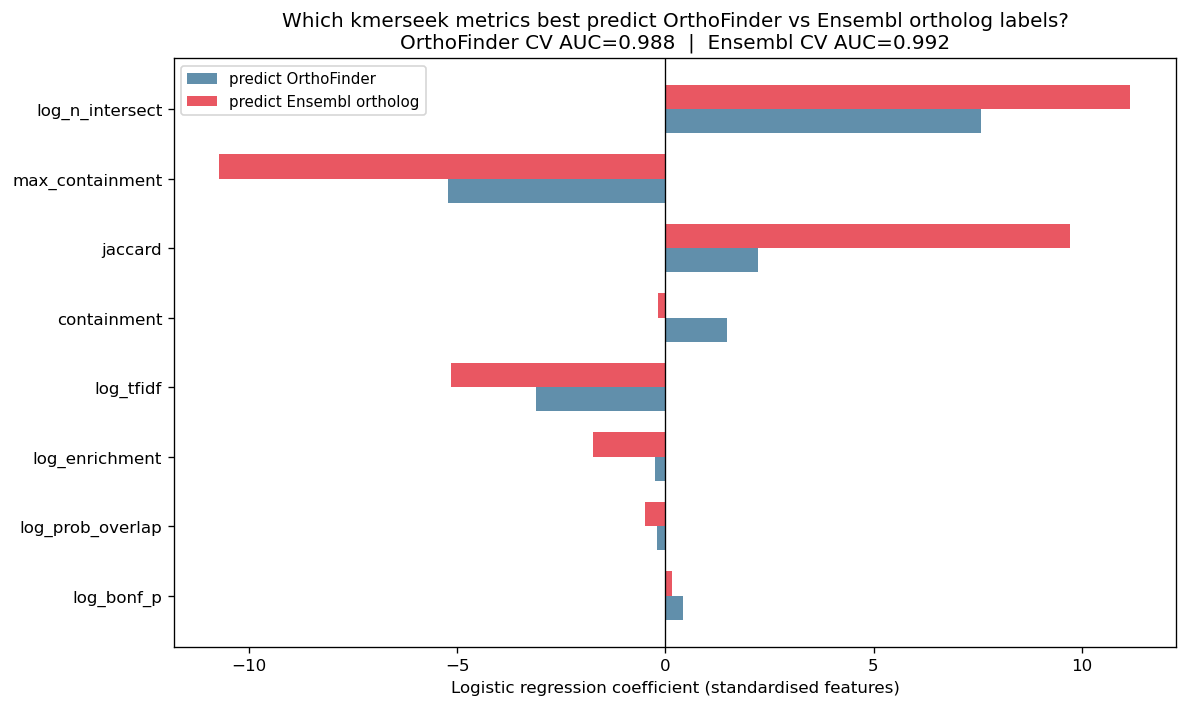

In [34]:
# Also fit LR to predict Ensembl ortholog (y_true), compare coefficients
pipe_ens = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, C=1.0)),
    ]
)
pipe_ens.fit(X, y_true.values)
coef_ens = pipe_ens.named_steps["lr"].coef_[0]

cv_auc_ens = cross_val_score(
    pipe_ens, X, y_true.values, cv=5, scoring="roc_auc", n_jobs=-1
)
print(
    f"5-fold CV ROC AUC (predicting Ensembl ortholog): {cv_auc_ens.mean():.4f} ± {cv_auc_ens.std():.4f}"
)

# Side-by-side coefficient plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(feature_names))
w = 0.35
ax.barh(
    x - w / 2,
    pipe.named_steps["lr"].coef_[0],
    w,
    label="predict OrthoFinder",
    color="#457b9d",
    alpha=0.85,
)
ax.barh(
    x + w / 2,
    pipe_ens.named_steps["lr"].coef_[0],
    w,
    label="predict Ensembl ortholog",
    color="#e63946",
    alpha=0.85,
)
ax.set_yticks(x)
ax.set_yticklabels(feature_names)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Logistic regression coefficient (standardised features)")
ax.set_title(
    "Which kmerseek metrics best predict OrthoFinder vs Ensembl ortholog labels?\n"
    f"OrthoFinder CV AUC={cv_auc.mean():.3f}  |  Ensembl CV AUC={cv_auc_ens.mean():.3f}"
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig(DATA_DIR / f"vs_orthofinder_logreg_coeffs.hp.k{KSIZE}.png", dpi=150)
plt.show()

In [35]:
# Decision boundary: what raw metric value corresponds to the LR threshold?
# For a single feature, the threshold is where log-odds = 0
# For interpretability: show the per-feature "effective cutoff" given others at median

scaler_fitted = pipe.named_steps["scaler"]
lr_fitted = pipe.named_steps["lr"]

print("Per-feature decision boundary (all other features at their median):")
print(
    f"{'Feature':25s}  {'Coeff':>8}  {'Median':>10}  {'Threshold (raw)':>18}  {'Unit'}"
)
print("-" * 80)

X_median = np.median(X, axis=0)

for i, fname in enumerate(feature_names):
    coef_i = lr_fitted.coef_[0, i]
    if abs(coef_i) < 1e-6:
        continue
    # Solve: intercept + sum(coef_j * scaled_x_j) = 0 at threshold for feature i
    # scaled_x_i = (x_i - mean_i) / std_i
    other_contrib = lr_fitted.intercept_[0]
    for j, c in enumerate(lr_fitted.coef_[0]):
        if j != i:
            other_contrib += (
                c * (X_median[j] - scaler_fitted.mean_[j]) / scaler_fitted.scale_[j]
            )
    # coef_i * (threshold_scaled) + other = 0
    threshold_scaled = -other_contrib / coef_i
    threshold_raw = threshold_scaled * scaler_fitted.scale_[i] + scaler_fitted.mean_[i]

    # Back-transform if log-scaled
    is_log = fname.startswith("log_")
    if is_log:
        threshold_display = 10**threshold_raw
        unit = "(original scale)"
    else:
        threshold_display = threshold_raw
        unit = ""

    print(
        f"  {fname:23s}  {coef_i:+8.3f}  {np.median(X[:,i]):10.3f}  {threshold_display:>18.4g}  {unit}"
    )

Per-feature decision boundary (all other features at their median):
Feature                       Coeff      Median     Threshold (raw)  Unit
--------------------------------------------------------------------------------
  log_bonf_p                 +0.423      -1.902                 inf  (original scale)
  log_prob_overlap           -0.198      -3.272          1.499e-106  (original scale)
  log_enrichment             -0.259       1.599           2.135e-19  (original scale)
  log_tfidf                  -3.096       3.608                 294  (original scale)
  containment                +1.473       0.010              0.6303  
  jaccard                    +2.224       0.004              0.3228  
  max_containment            -5.222       0.015             -0.1722  
  log_n_intersect            +7.569       0.778               36.05  (original scale)


/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_51179/2121954363.py:31: RuntimeWarning: overflow encountered in scalar power
  threshold_display = 10 ** threshold_raw


## 17. Verdict

**A p-value threshold is not a usable ortholog caller.** Every correction lands in the same place:
recall 0.998-1.000 at precision 0.040-0.092, best F1 0.168 (Bonferroni p<1e-5) against OrthoFinder's
0.960 (precision 0.991, recall 0.931). Bonferroni at 0.05 predicts 499,074 pairs to OrthoFinder's
32,320. The correction is not the problem, since raw, BH and Bonferroni all give the same 0.666 best
F1 once swept as a continuous score in section 11. The Poisson null is the problem. This is the
result notebook 200 acts on when it switches the whole comparison to reciprocal best hit.

**Swept as continuous scores instead of thresholded tests, kmerseek's metrics are much better but
still short.** Best F1 by metric: containment 0.715, n_intersecting 0.712, enrichment 0.690,
poisson_p 0.666, prob_overlap 0.210, query_tfidf 0.165. Product scores in section 15 add a little:
c x e x j reaches F1 0.730 at precision 0.910, e x j 0.729, against ROC AUCs clustered at
0.968-0.983 for everything except prob_overlap (0.608) and query_tfidf (0.568). The ceiling across
all of them is F1 ≈ 0.73 at recall ≈ 0.61, so the gap to OrthoFinder is recall, not precision.

**`prob_overlap` and `query_tfidf` should be retired as ranking scores.** They are the only two
metrics below ROC AUC 0.61, and they are also the two on which false positives most often exceed the
true-positive median (24.7% and 48.9%, against 0.2-0.3% for containment, enrichment and
n_intersecting). They carry length and composition signal, not homology signal.

**The false positives are not paralogs.** This is the section that settles it, and it contradicts
the hypothesis section 13 was written to test. Of 464,735 Bonferroni false positives, 0.1% (273)
share an OrthoFinder orthogroup with their partner, against 93.2% (32,015/34,339) of true positives
and 0.0% background. The gene-name-prefix proxy agrees at 0.0% vs 0.2% and is too weak to add
anything either way. At this threshold the false positives are noise. Notebook
[217](./217_rbh_false_positive_paralog_contamination.ipynb) revisits the question against RBH's much
more selective calls and finds 42-65% same-orthogroup there, so "kmerseek's errors are paralog
swaps" is a statement about RBH, not about the p-value threshold, and the two must not be quoted
interchangeably.

**Section 14 shows the false positives are weak on every axis that matters.** Median containment
0.021 for FPs against 0.327 for TPs, median n_intersecting_hashes 12 against 214, median
log10(enrichment) 1.762 against 3.192. They sit just above the background sample (containment 0.004,
3 hashes) rather than anywhere near real orthologs. Nothing here suggests a population of real
homologs missing from Ensembl.

**The 2,324 kmerseek-only Ensembl orthologs are the one place kmerseek adds coverage**, against 26
in the other direction, but at Bonferroni<0.05 they arrive inside 464,735 false positives, so this
notebook cannot separate them. Notebook 200 section 5 redoes this under RBH and gets 1,114
kmerseek-only pairs at a workable precision, roughly two-thirds of them in multi-gene MGI homology
classes.

**Logistic regression tops out where the single metrics do.** 5-fold CV ROC AUC 0.9877 predicting
OrthoFinder calls and 0.9922 predicting Ensembl orthologs, with log_n_intersect (+7.57) and
max_containment (-5.22) dominating. High AUC at 3-4% prevalence again does not translate into
precision, and the model does not beat the c x e x j product on F1, so there is no case for carrying
a fitted classifier forward.

**Caveat on ground truth.** Sections 1-12 score against Ensembl/OrthoFinder while later branch work
scores against MGI, and the two disagree on the tail. Numbers here are not directly comparable to
notebook 200's F1 values.